# **DATA LOADING**

In [ ]:
import warnings
# To ignore all warnings
warnings.filterwarnings("ignore")

### **Library**

In [ ]:
pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import struct
import requests
import umap.umap_ as umap
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from collections import Counter
from skimage.feature import hog
from sklearn.metrics import  precision_score, recall_score, f1_score

from cuml.linear_model import LogisticRegression as cuMLLogisticRegression
from cuml.metrics import accuracy_score,confusion_matrix
from cuml.preprocessing import MinMaxScaler
import cupy as cp
import time
from cuml.svm import LinearSVC
from cuml.svm import SVC

In [ ]:
# Link raw GitHub
train_images_url = 'https://raw.githubusercontent.com/LeeTunMT/Team_Lab1_PR/group1/DataSet_Fashion-MNIST/train-images-idx3-ubyte'
train_labels_url = 'https://raw.githubusercontent.com/LeeTunMT/Team_Lab1_PR/group1/DataSet_Fashion-MNIST/train-labels-idx1-ubyte'
test_images_url = 'https://raw.githubusercontent.com/LeeTunMT/Team_Lab1_PR/group1/DataSet_Fashion-MNIST/t10k-images-idx3-ubyte'
test_labels_url = 'https://raw.githubusercontent.com/LeeTunMT/Team_Lab1_PR/group1/DataSet_Fashion-MNIST/t10k-labels-idx1-ubyte'

# Function to download files from a URL
def download_file(url, filename):
    response = requests.get(url)
    with open(filename, 'wb') as f:
        f.write(response.content)

# Function to load the image files
def load_images(file_path):
    with open(file_path, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.fromfile(f, dtype=np.uint8).reshape(num_images, rows * cols)
    return images

# Function to load the label files
def load_labels(file_path):
    with open(file_path, 'rb') as f:
        magic, num_labels = struct.unpack(">II", f.read(8))
        labels = np.fromfile(f, dtype=np.uint8)
    return labels

# Tải dữ liệu từ GitHub
download_file(train_images_url, 'train-images-idx3-ubyte')
download_file(train_labels_url, 'train-labels-idx1-ubyte')
download_file(test_images_url, 't10k-images-idx3-ubyte')
download_file(test_labels_url, 't10k-labels-idx1-ubyte')

# Loading training data
train_images = load_images('train-images-idx3-ubyte')
train_labels = load_labels('train-labels-idx1-ubyte')

# Loading testing data
test_images = load_images('t10k-images-idx3-ubyte')
test_labels = load_labels('t10k-labels-idx1-ubyte')

print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)


Training images shape: (60000, 784)
Training labels shape: (60000,)
Test images shape: (10000, 784)
Test labels shape: (10000,)


#  **Exploratory Data Analysis (EDA)**

### **Show Some Image of each Class**

In [ ]:
def showOneImage(row, df=train_images, colors="gray"):
    plt.imshow(df[row].reshape(28, 28), cmap=colors)
    plt.xticks([])
    plt.yticks([])
    plt.show()

# Function to display multiple images of a given label
def showLabel(label, df=train_images, labels=train_labels, n=50):
    labelselect = df[labels == label]
    plt.figure(figsize=(10, 5), dpi=150)
    for i in range(min(n, len(labelselect))):
        plt.subplot(n // 10, 10, i + 1)
        image_data = labelselect[i].reshape(28, 28)
        plt.imshow(image_data, cmap='gray')
        plt.xticks([])
        plt.yticks([])
    plt.show()

'label 0'

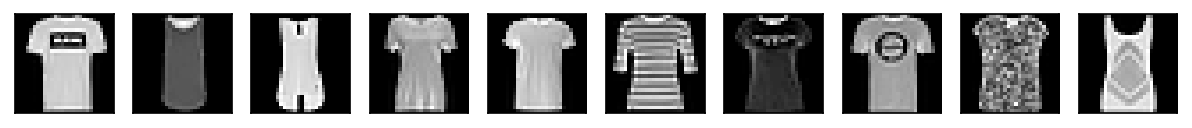

'label 1'

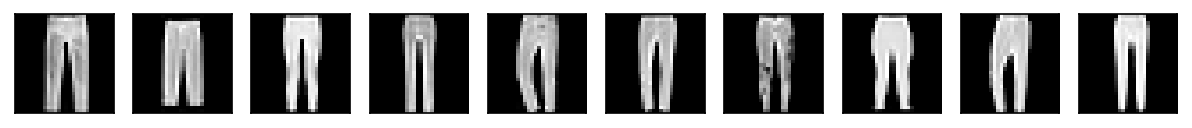

'label 2'

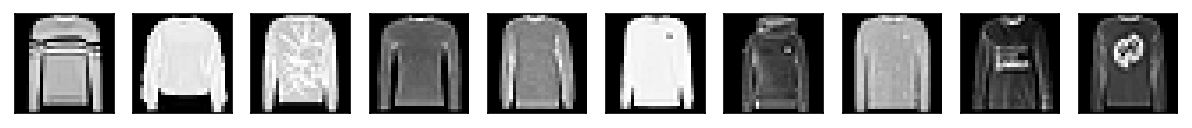

'label 3'

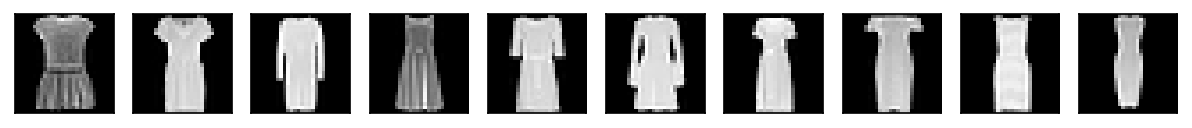

'label 4'

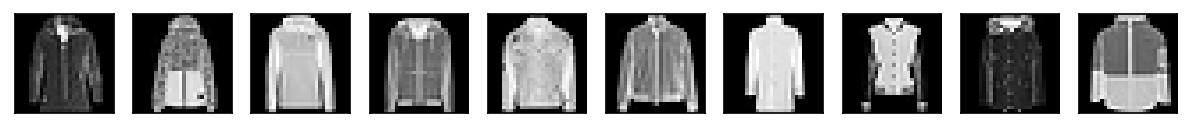

'label 5'

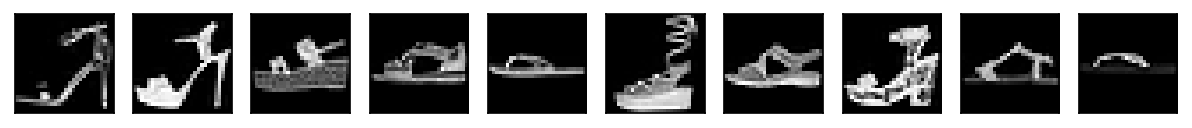

'label 6'

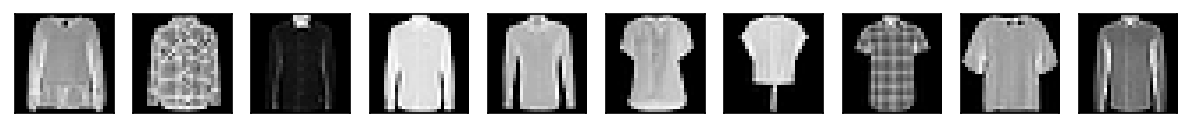

'label 7'

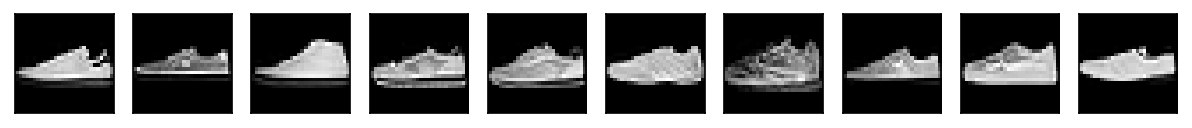

'label 8'

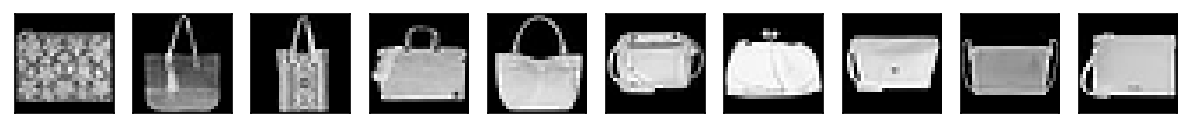

'label 9'

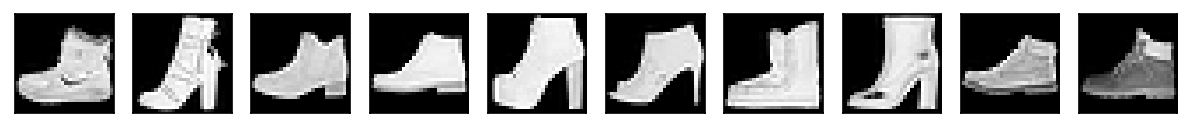

In [ ]:
for label in range(10):
    display(f"label {label}")
    showLabel(label, n=10)

### **Frequency of the data**

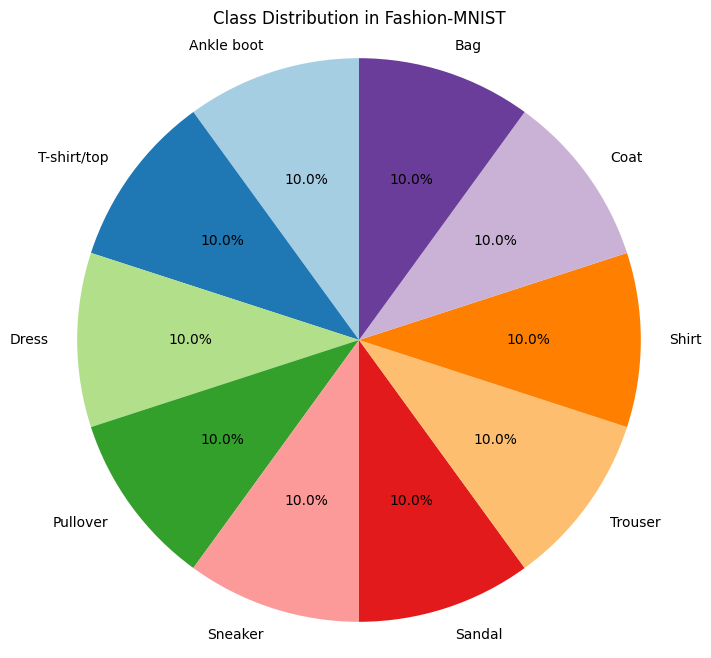

In [ ]:
# List of class names for the train_images
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def class_distribution(labels):
    class_counts = Counter(labels)
    counts = list(class_counts.values())
    classes = [class_names[i] for i in class_counts.keys()]

    plt.figure(figsize=(8, 8))
    plt.pie(counts, labels=classes, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors) # using pie chart
    plt.title('Class Distribution in Fashion-MNIST')
    plt.axis('equal')
    plt.show()

# Distribution of train_lables
class_distribution(train_labels)

> The number of each layer is the same => **The dataset is balanced**


---



### **Visualization using UMAP**


> **UMAP (Uniform Manifold Approximation and Projection) is a dimensionality reduction technique that is particularly effective for visualizing high-dimensional data. It is based on manifold learning techniques and topological data analysis.**

> **Using UMAP on Fashion MNIST can help in visualizing the high-dimensional pixel data in a 2D space, making it easier to understand the distribution and clustering of different fashion items.**

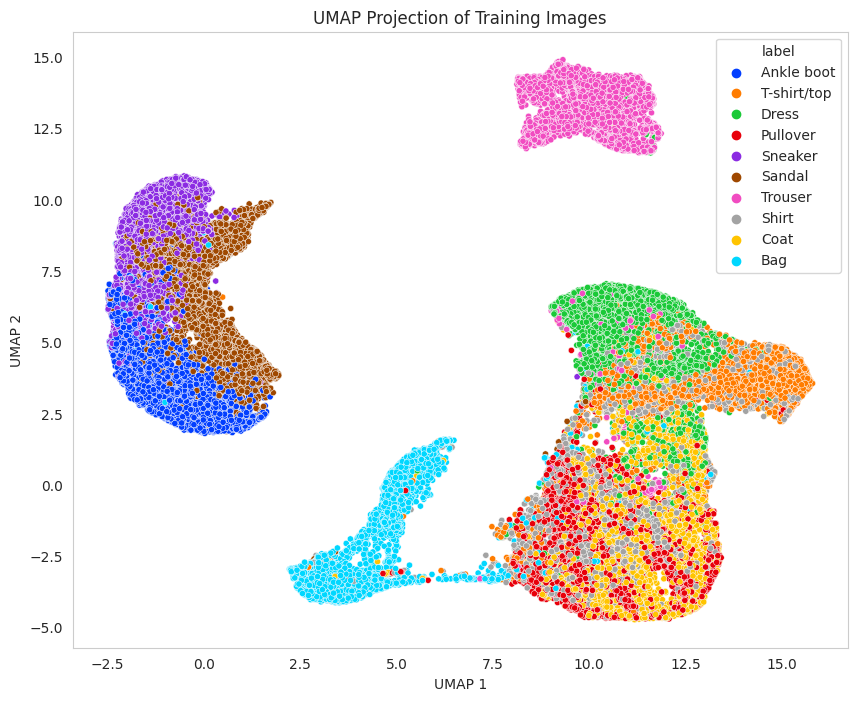

In [ ]:
# Apply UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
train_images_umap = reducer.fit_transform(train_images)

# Create DataFrame
df = pd.DataFrame(train_images_umap, columns=('x', 'y'))
df["label"] = train_labels

# Replace Class Labels using class_names list
df["label"] = df["label"].apply(lambda x: class_names[x])

# Visualize the results with vibrant colors
sns.set_style("whitegrid", {'axes.grid': False})
palette = sns.color_palette("bright", 10)  # Use a bright color palette
plt.figure(figsize=(10, 8))
sns.scatterplot(x="x", y="y", hue="label", palette=palette, data=df, legend='full', s=20)  # Adjust `s` as needed
plt.title('UMAP Projection of Training Images')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

- **Clear clusters:** Classes like Bag, and Trouser form clear, distinct clusters, making them easier for the model to classify.

- **Overlap between classes:** Dress, Pullover, and Coat show overlap, indicating similar features that could lead to misclassification.

- **Scattered distribution:** Ankle Boot and Sandal are scattered, suggesting diverse samples that might make classification more challenging for the model.

> This UMAP projection provides insights into class similarities and separability, emphasizing that while most classes form distinct clusters, some visually similar classes exhibit overlap. This shows that with linear models (such as Logistic Regression), it will require more complex and challenging processing to separate these classes.


---



### **Pixel Distribution of each Class**


> Examine the pixel distribution for each class because some classes may have more dark pixels (low values), while others have more bright pixels (high values).





1. **Undersatanding the Characteristics of Each Class**
* Each class in the fashion-MNIST dataset represents a different type of clothing (such as T-shirt, Pants, Shoes, Bag, etc.). Visualizing the pixel distribution for each class allows us to observe the unique characteristics of each type of clothing.
* For example, some classes may have more pixels with darker values (such as background or border pixels), while others may have brighter pixel values (highlighted areas). This helps us gain a deeper understanding of the data distribution for each class.

2. **Detecting Differences and Similarities Between Classes**
* By examining these distribution plots, we can quickly compare classes to detect which classes have similar or distinct pixel characteristics. For example:
  * If two classes have similar pixel distributions, they may be harder to differentiate and could cause classification confusion.
  * If they have clearly distinct distributions, the model will have an advantage in separating these classes.
* This is especially important when using classification models like logistic regression or SVM, as the model may struggle if two classes have many similar pixel values.

3. **Identifying Data Imbalance and Anomalies**
* The distribution plots can also help detect anomalies in the data, such as:
  * A class with a pixel value distribution that is significantly different from the others.
  * The existence of outlier pixel values, or an uneven distribution in a specific class, which could indicate noise or quality issues in that class’s data.
* Detecting these anomalies can help us adjust the data before training the model, potentially improving classification performance.

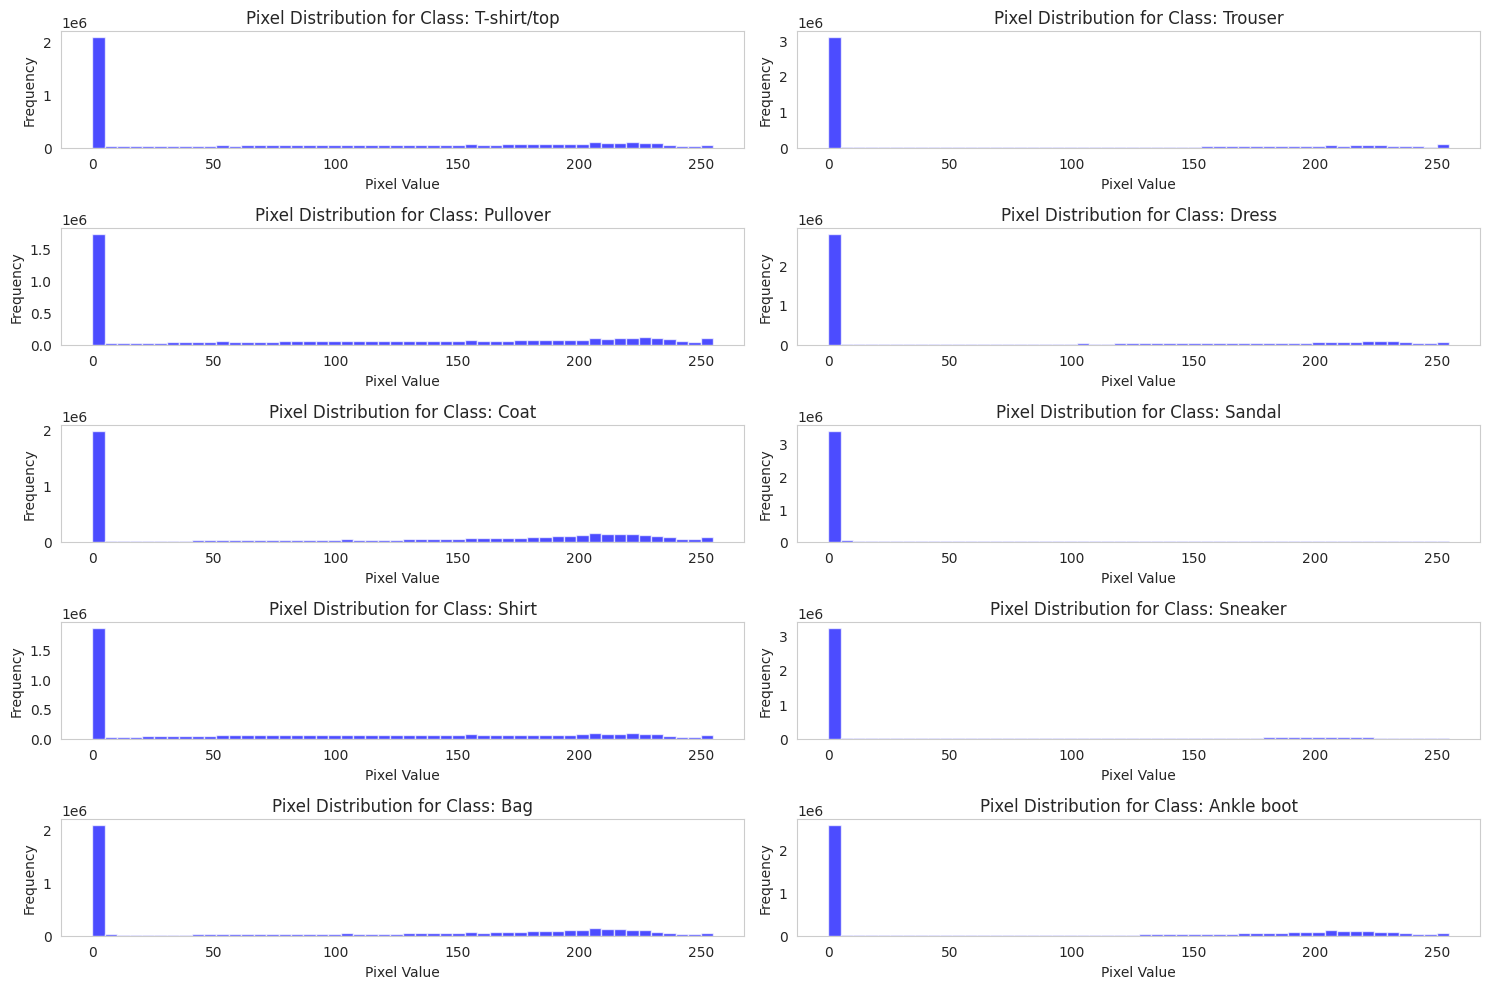

In [ ]:
# Visualize distibution of each class
def plot_pixel_distribution_by_class(images, labels, class_names):
    plt.figure(figsize=(15, 10))

    for i in range(10):
        class_images = images[labels == i]
        class_images_flat = class_images.reshape(-1)

        plt.subplot(5, 2, i+1)
        plt.hist(class_images_flat, bins=50, color='blue', alpha=0.7)
        plt.title(f'Pixel Distribution for Class: {class_names[i]}')
        plt.xlabel('Pixel Value')
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

plot_pixel_distribution_by_class(train_images, train_labels, class_names)


>We can see **values .0** that are too dominant. So I adjust excluded_value to filter out other dominant pixel values such as 0 (representing black or background pixels) and plot again.


---



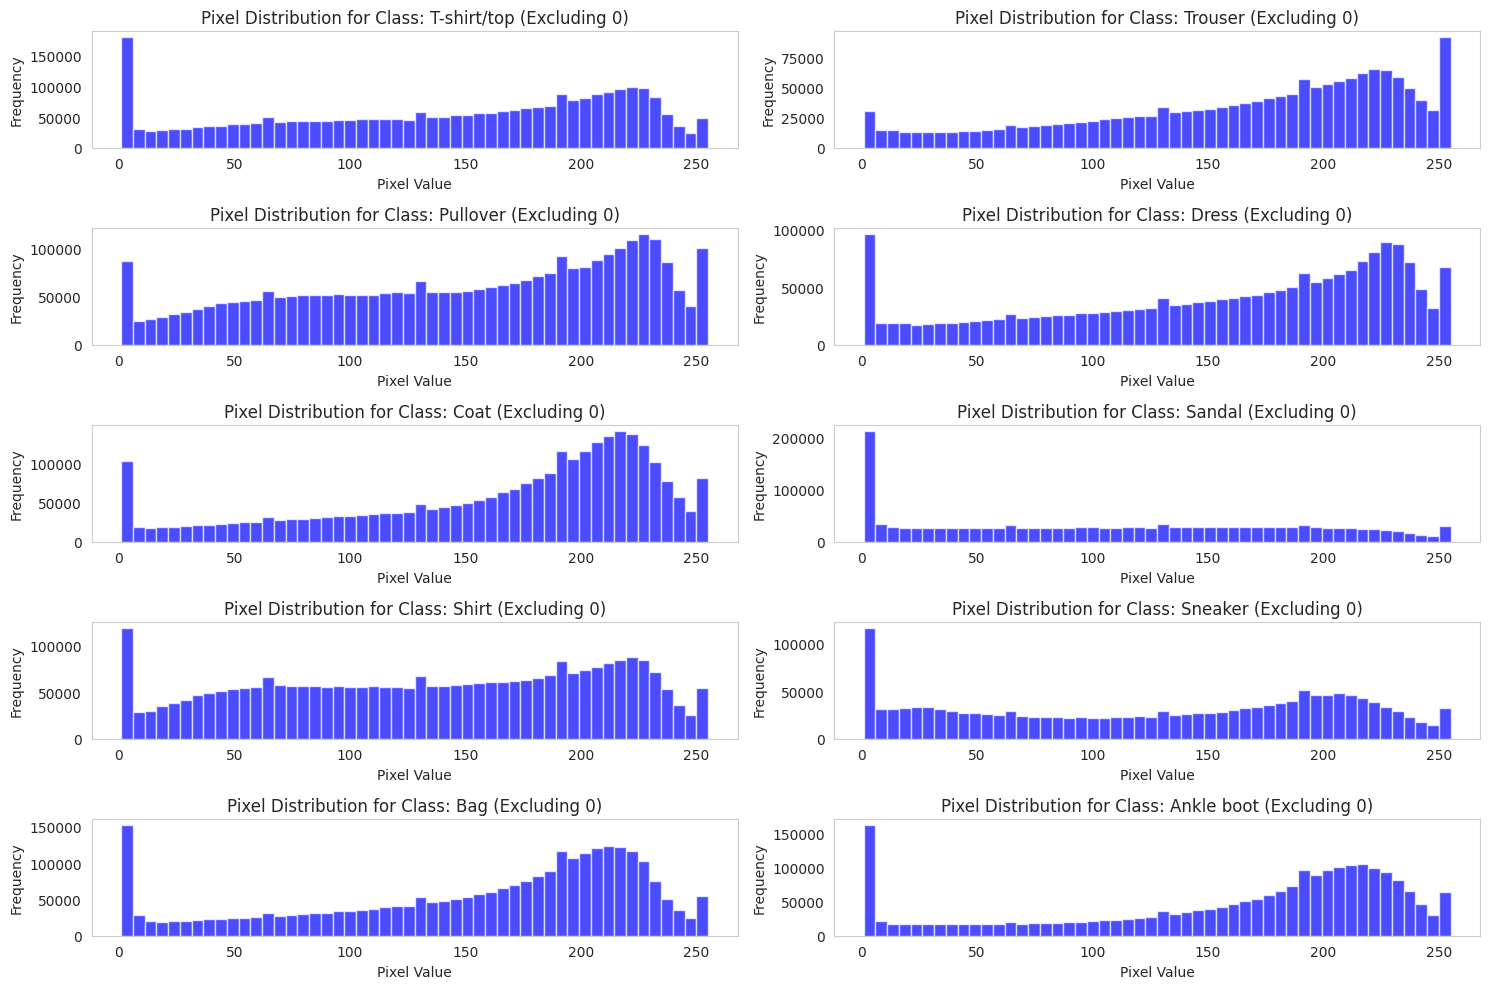

In [ ]:
# Function to plot pixel intensity distribution for each class excluding certain pixel values
def plot_pixel_distribution_excluding_values(images, labels, class_names, excluded_value=0):
    plt.figure(figsize=(15, 10))

    for i in range(10):
        class_images = images[labels == i]
        class_images_flat = class_images.reshape(-1)

        # Exclude pixels with the given value (e.g., 0)
        class_images_filtered = class_images_flat[class_images_flat != excluded_value]

        plt.subplot(5, 2, i+1)
        plt.hist(class_images_filtered, bins=50, color='blue', alpha=0.7)
        plt.title(f'Pixel Distribution for Class: {class_names[i]} (Excluding {excluded_value})')
        plt.xlabel('Pixel Value')
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

plot_pixel_distribution_excluding_values(train_images, train_labels, class_names)

### **Pixel Intensity Distribution Analysis by Class**
- #### **Classes with Similar Intensity Distribution:**

> In general, the classes “T-shirt/top,” “Pullover,” “Coat,” and “Shirt” have
relatively even pixel intensity distributions, with many pixels concentrated at higher intensities (around 0.7 to 1). This could be due to the uniform color and minimal detail in these clothing items compared to other classes.

- #### **Class with Lower Intensity Concentration:**

> The classes “Sandal” and “Sneaker” show lower pixel intensity distributions at high values, indicating more pixels in darker or grayish regions. This likely reflects the footwear characteristics in the dataset, as they tend to have larger dark or solid-colored areas.

- #### **Classes “Bag” and “Ankle Boot”:**

> Both of these classes have a similar pixel distribution, with intensities higher around values between 0.5 and 1. This may be due to the shapes of bags and boots, which cover more of the frame, resulting in more high-intensity pixels.

- #### **Class “Trouser”:**

>This class has a distinct distribution, with a concentration of pixels at intensities close to 1, indicating that trousers in the dataset tend to have uniform and brighter colors in many areas, particularly along the pant legs.

---



### **Heat map for correlation label**

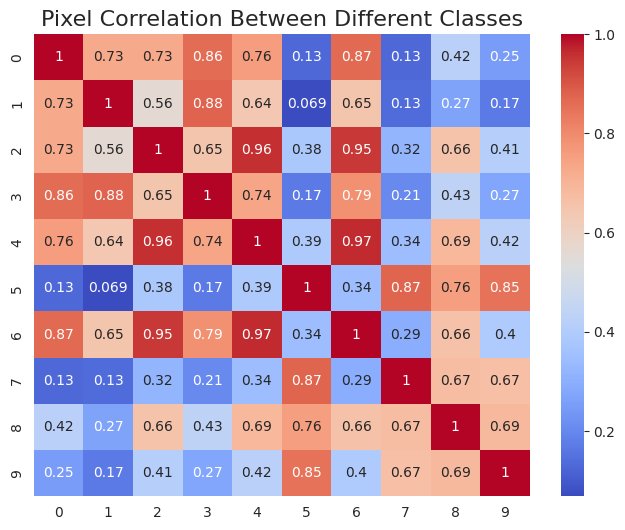

In [ ]:
# Built correlation matrix

class_images = {label: train_images[train_labels == label] for label in range(10)}

# Calculate the average image of each layer
mean_images = {label: np.mean(images, axis=0) for label, images in class_images.items()}

# Calculate the correlation matrix between classes
correlation_matrix = np.corrcoef([mean_image.flatten() for mean_image in mean_images.values()])

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", xticklabels=np.unique(train_labels), yticklabels=np.unique(train_labels))
plt.title("Pixel Correlation Between Different Classes", fontsize=16)
plt.show()

- #### **High Correlation Between Certain Classes:**

> Some classes have a high correlation with each other, such as class 4 (Coat) and class 6 (Shirt), as well as class 2 (Pullover) and class 4 (Coat),... This may be due to these classes having similar styles or characteristics, leading to similar pixel distributions.

- #### **Low Correlation Between Other Classes:**

> Classes like 1 (Trouser) and 5 (Sandal) have lower correlations with other classes, clearly reflecting differences in pixel structure. This is reasonable, as images in these classes have distinct shapes and features (e.g., trousers and footwear).

- ***Conclusion: The correlation coefficient of some classes is quite large => easily causes confusion, and reduces the performance of the model, especially logistic regression because the way this model operates is closely related to the correlation of the data of the classes. This helps determine the appropriate classification method, especially when there are multiple highly correlated classes (One-vs-Rest or Softmax).***


---




# P**REPROCESSING**

In [ ]:
# Convert data from numpy array to cupy array to use GPU
train_images = cp.asarray(train_images)
train_labels = cp.asarray(train_labels,dtype=cp.int32)
test_images = cp.asarray(test_images)
test_labels = cp.asarray(test_labels, dtype=cp.int32)

In [ ]:
# Scale
scaler = MinMaxScaler()
train_images = scaler.fit_transform(train_images)
test_images = scaler.fit_transform(test_images)

# **Model Training**

> **Method and Libraries:** Use cuML instead of scikit-learn to enable GPU-accelerated training. As part of NVIDIA’s RAPIDS AI suite, cuML speeds up model training on large datasets by leveraging GPU power, which scikit-learn doesn’t support.

> **Processing Unit:** use GPU T4 x2 on Kaggle


---



## **Linear Model - LogisticRegression**

### **Parameter**

**`solver: ‘qn’ (default=’qn’)`**

> Algorithm to use in the optimization problem. Currently only qn is supported, which automatically selects either L-BFGS or OWL-QN depending on the conditions of the l1 regularization described above.

**`max_iter: int (default = 1000)`**

> Maximum number of iterations taken for the solvers to converge.

**`penalty: ‘none’, ‘l1’, ‘l2’, ‘elasticnet’ (default = ‘l2’)`**

> Used to specify the norm used in the penalization. If ‘none’ or ‘l2’ are selected, then L-BFGS solver will be used. If ‘l1’ is selected, solver OWL-QN will be used. If ‘elasticnet’ is selected, OWL-QN will be used if l1_ratio > 0, otherwise L-BFGS will be used.

**`fit_intercept: boolean (default = True)`**

> If True, the model tries to correct for the global mean of y. If False, the model expects that you have centered the data.

**`C: float (default = 1.0)`**

> Inverse of regularization strength; must be a positive float.


---




### **Softmax Regression**

> Softmax regression is known by various names, including polytomous logistic regression, multiclass logistic regression, multinomial logit (mlogit), the maximum entropy classifier (MaxEnt), and the conditional maximum entropy model. However, the most common name is `Multinomial Logistic Regression`.

> In statistics, Softmax is a classification method that generalizes logistic regression to multiclass problems, i.e. with more than two possible discrete outcomes. That is, it is a model that is used to predict the probabilities of the different possible outcomes of a categorically distributed dependent variable, given a set of independent variables (which may be real-valued, binary-valued, categorical-valued, etc.).

>**Logistic Regression using Softmax in cuML:** cuML’s LogisticRegression can take array-like objects, either in host as NumPy arrays or in device (as Numba or __cuda_array_interface__ compliant), in addition to cuDF objects. It provides both single-class (using sigmoid loss) and multiple-class (using softmax loss) variants, depending on the input variables.

In [ ]:
# Train Logistic Regression with multiple-class (Softmax Regression)
softmax_model = cuMLLogisticRegression(max_iter=3000, solver='qn', fit_intercept=True) # multiple-class (using softmax loss) variants, depending on the input variables

start_time = time.time()
softmax_model.fit(train_images, train_labels)
end_time = time.time()

# Calculate training time
softmax_training_time = end_time - start_time

Training time: 77.59s
Accuracy: 0.8440
Precision: 0.8428
Recall: 0.8440
F1 Score: 0.8432


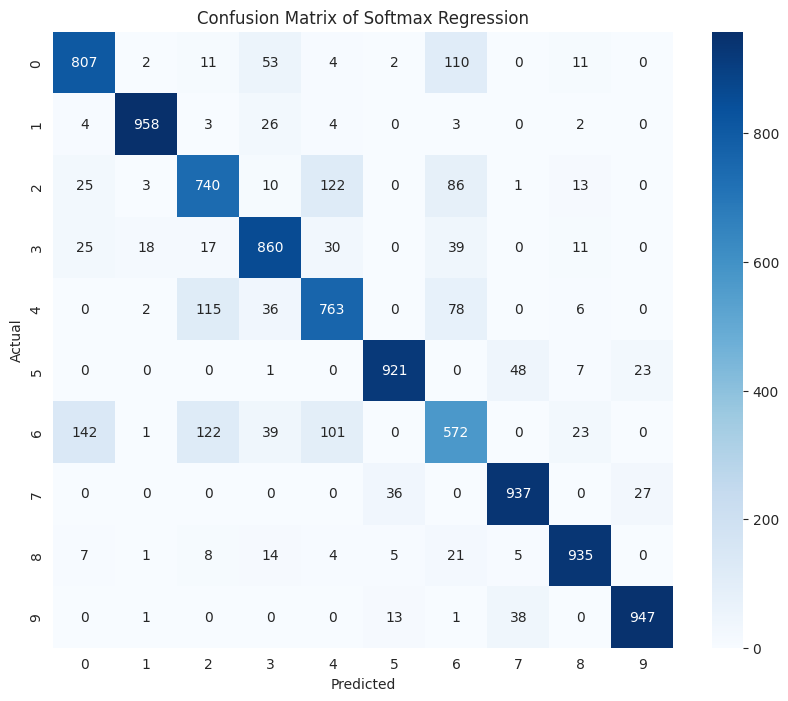

In [ ]:
# Make predict on test-set
test_predictions = softmax_model.predict(test_images)
pred_softmax = test_predictions

# Evaluate softmax Regression model
softmax_accuracy = accuracy_score(test_labels, test_predictions)
softmax_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
softmax_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
softmax_f1 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')

print(f"Training time: {softmax_training_time:.2f}s")
print(f"Accuracy: {softmax_accuracy:.4f}")
print(f"Precision: {softmax_precision:.4f}")
print(f"Recall: {softmax_recall:.4f}")
print(f"F1 Score: {softmax_f1:.4f}")

# Confusion matrix
softmax_conf_matrix = confusion_matrix(test_labels, test_predictions)
softmax_conf_matrix = cp.asnumpy(softmax_conf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(softmax_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of Softmax Regression')
plt.show()

#### **Observation from Score:**

* **Accuracy:** The model achieves an accuracy of 84.40%, indicating it correctly predicts 84.40% of the samples in the test set. This is a solid result, showing that the model is fairly accurate in its classification.
* **Precision:** The precision is 84.28%, meaning that 84.28% of the model's positive predictions are correct.
* **Recall:** The recall is 84.40%, showing that the model successfully identifies 84.40% of the actual positive samples among all positive samples.
* **F1 Score:** With an F1 Score of 84.32%, the model achieves a good balance between precision and recall. This high F1 Score suggests the model performs well on both precision and recall.


---



#### **Observation from Confusion Matrix**

In [ ]:
# Filter and print classes with correctly classified samples >= 900
for class_idx in range(softmax_conf_matrix.shape[0]):
    correct_predictions = softmax_conf_matrix[class_idx, class_idx]
    if correct_predictions >= 900:
        print(f"Class '{class_names[class_idx]}' has {correct_predictions} correctly classified samples.")

Class 'Trouser' has 958 correctly classified samples.
Class 'Sandal' has 921 correctly classified samples.
Class 'Sneaker' has 937 correctly classified samples.
Class 'Bag' has 935 correctly classified samples.
Class 'Ankle boot' has 947 correctly classified samples.


> Class **'Trouser', 'Sandal', 'Sneaker', 'Bag', 'Ankle'** have high accuracy with over 900 correct predictions and minimal misclassifications.


---



In [ ]:
# Filter and print class pairs with more than 100 misclassified samples, using class names
for actual_class in range(softmax_conf_matrix.shape[0]):
    for predicted_class in range(softmax_conf_matrix.shape[1]):
        if actual_class != predicted_class and softmax_conf_matrix[actual_class, predicted_class] > 100:
            print(f"Actual class '{class_names[actual_class]}' misclassified as '{class_names[predicted_class]}': {softmax_conf_matrix[actual_class, predicted_class]} samples")

Actual class 'T-shirt/top' misclassified as 'Shirt': 110 samples
Actual class 'Pullover' misclassified as 'Coat': 122 samples
Actual class 'Coat' misclassified as 'Pullover': 115 samples
Actual class 'Shirt' misclassified as 'T-shirt/top': 142 samples
Actual class 'Shirt' misclassified as 'Pullover': 122 samples
Actual class 'Shirt' misclassified as 'Coat': 101 samples


**There are 4 pairs of classes that are easily confused:**
* 'T-shirt/top' vs 'Shirt'
* 'Pullover' vs 'Coat'
* 'Shirt' vs 'Pullover'
* 'Shirt' vs 'Coat'


---



### **With Logistic Regression, we have two strategies for multi-label classification:**:

* **One-Vs-One:** In this approach, for each pair of different classes, we create a binary classifier to distinguish between them, then use voting to determine the winning class. Finally, we choose the class with the most votes as the predicted class for the data point.
> This strategy helps reduce misclassification by comparing each pair of classes individually. However, it requires creating a large number of classifiers and may result in redundant classifiers.

* **One-Vs-Rest:** Here, we create classifiers between one class and all other classes, then select the class with the highest probability as the predicted class for the data point
> This strategy reduces the number of classifiers and computational complexity. However, it may produce poor results if there is a large imbalance in class labels or if data points are not clearly distinguishable from the rest.


---




### **Logistic Regression (One vs Rest)**

In [ ]:
from cuml.multiclass import OneVsOneClassifier, OneVsRestClassifier

Training time :  22.837
Accuracy : 0.8413000106811523
Precision score : 0.8392018875067431 
Recall score: 0.8413
F1 score : 0.8396081873975083 


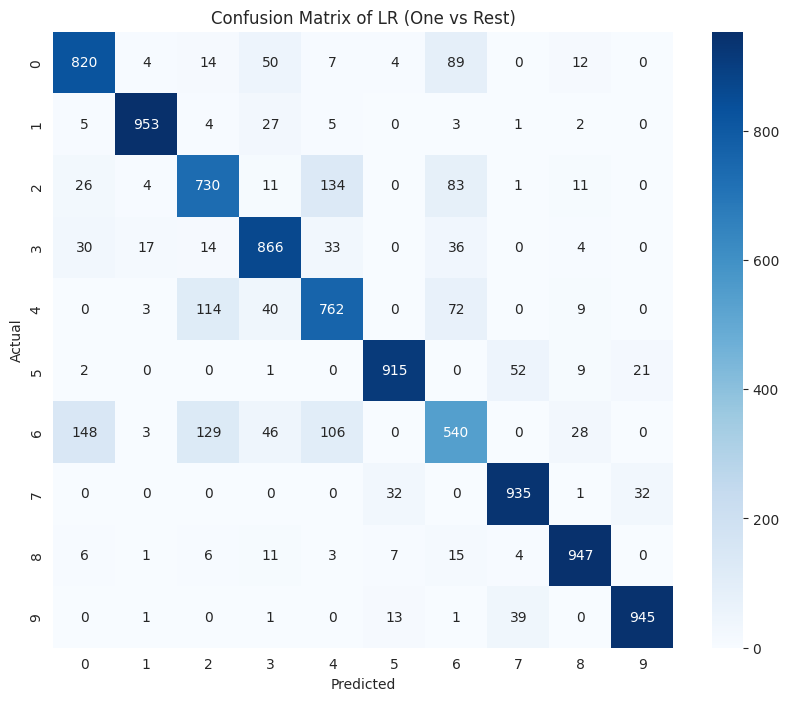

In [ ]:
ovr_model=OneVsRestClassifier(cuMLLogisticRegression(max_iter=3000))


start=time.time()
ovr_model.fit(train_images, train_labels)
ovr_training_time =time.time()-start

preds = ovr_model.predict(test_images)
pred_ovr = preds

ovr_accuracy = accuracy_score(test_labels,preds)
ovr_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovr_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovr_f1_score = f1_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')


print(f"Training time : {ovr_training_time : .3f}")
print(f"Accuracy : {ovr_accuracy}")
print(f"Precision score : {ovr_precision:} " )
print(f"Recall score: {ovr_recall}")
print(f"F1 score : {ovr_f1_score} ")

# Confusion matrix
ovr_conf_matrix = confusion_matrix(test_labels.astype('int32'),preds)
ovr_conf_matrix = cp.asnumpy(ovr_conf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(ovr_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of LR (One vs Rest)')
plt.show()

#### **Observation from Score**

* **Accuracy:** The model achieves an accuracy of 84.13%, indicating it correctly predicts 84.13% of the samples in the test set. This is a good result, reflecting the model’s stable classification ability.

* **Precision:** The precision is 83.92%, meaning 83.92% of the model's positive predictions are correct.

* **Recall:** The recall is 84.13%, showing that the model correctly identifies 84.13% of the actual positive samples among all positive samples.

* **F1 Score:** The F1 Score is 83.96%, demonstrating a good balance between precision and recall. This high F1 Score indicates that the model performs well on both aspects.

#### **Observation from Confusion Matrix**

In [ ]:
# Filter and print classes with correctly classified samples >= 900
for class_idx in range(ovr_conf_matrix.shape[0]):
    correct_predictions = ovr_conf_matrix[class_idx, class_idx]
    if correct_predictions >= 900:
        print(f"Class '{class_names[class_idx]}' has {correct_predictions} correctly classified samples.")

Class 'Trouser' has 953 correctly classified samples.
Class 'Sandal' has 915 correctly classified samples.
Class 'Sneaker' has 935 correctly classified samples.
Class 'Bag' has 947 correctly classified samples.
Class 'Ankle boot' has 945 correctly classified samples.


> Class **'Trouser', 'Sandal', 'Sneaker', 'Bag', 'Ankle'** have high accuracy with over 900 correct predictions and minimal misclassifications. (almost similar to sofrmax model)


---



In [ ]:
# Filter and print class pairs with more than 100 misclassified samples, using class names
for actual_class in range(ovr_conf_matrix.shape[0]):
    for predicted_class in range(ovr_conf_matrix.shape[1]):
        if actual_class != predicted_class and softmax_conf_matrix[actual_class, predicted_class] > 100:
            print(f"Actual class '{class_names[actual_class]}' misclassified as '{class_names[predicted_class]}': {softmax_conf_matrix[actual_class, predicted_class]} samples")

Actual class 'T-shirt/top' misclassified as 'Shirt': 110 samples
Actual class 'Pullover' misclassified as 'Coat': 122 samples
Actual class 'Coat' misclassified as 'Pullover': 115 samples
Actual class 'Shirt' misclassified as 'T-shirt/top': 142 samples
Actual class 'Shirt' misclassified as 'Pullover': 122 samples
Actual class 'Shirt' misclassified as 'Coat': 101 samples


**There are 4 pairs of classes that are easily confused:**
* 'T-shirt/top' vs 'Shirt'
* 'Pullover' vs 'Coat'
* 'Shirt' vs 'Pullover'
* 'Shirt' vs 'Coat'

***Similar to the softmax model***

---



### **Logistic Regression (One vs One)**

Training time :  15.534
Accuracy : 0.8501999974250793
Precision score : 0.8489652677658353 
Recall score: 0.8502000000000001
F1 score : 0.8494824793087445 


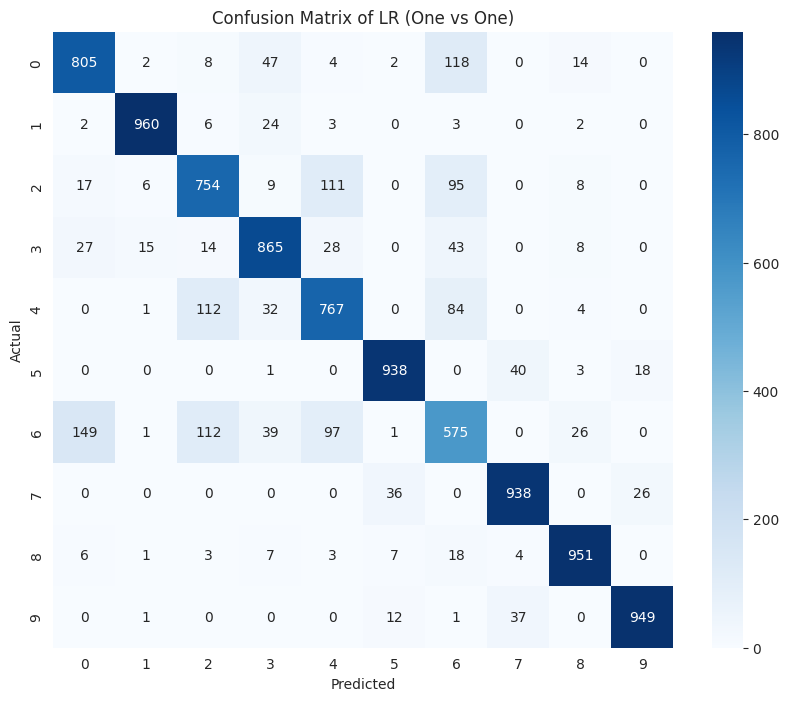

In [ ]:
ovo_model=OneVsOneClassifier(cuMLLogisticRegression(max_iter=3000))


start=time.time()
ovo_model.fit(train_images, train_labels)
ovo_training_time =time.time()-start

preds =ovo_model.predict(test_images)
pred_ovo = preds

ovo_accuracy = accuracy_score(test_labels,preds)
ovo_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovo_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovo_f1_score = f1_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')


print(f"Training time : {ovo_training_time : .3f}")
print(f"Accuracy : {ovo_accuracy}")
print(f"Precision score : {ovo_precision:} " )
print(f"Recall score: {ovo_recall}")
print(f"F1 score : {ovo_f1_score} ")

# Confusion matrix
ovo_conf_matrix = confusion_matrix(test_labels.astype('int32'),preds)
ovo_conf_matrix = cp.asnumpy(ovo_conf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(ovo_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of LR (One vs One)')
plt.show()

#### **Observation from Score**

* **Accuracy:** The model achieves an accuracy of 85.00%, meaning it correctly predicts 85.00% of the samples in the test set, indicating a strong overall classification performance.

* **Precision:** The precision is 84.87%, indicating that 84.87% of the model's positive predictions are correct.

* **Recall:** The recall is 85.00%, meaning the model successfully identifies 85.00% of the actual positive samples among all positive samples.

* **F1 Score:** With an F1 Score of 84.92%, the model shows a balanced performance between precision and recall, highlighting its effectiveness in both aspects.

#### **Observation from Confusion Matrix**

In [ ]:
# Filter and print classes with correctly classified samples >= 900
for class_idx in range(ovo_conf_matrix.shape[0]):
    correct_predictions = ovo_conf_matrix[class_idx, class_idx]
    if correct_predictions >= 900:
        print(f"Class '{class_names[class_idx]}' has {correct_predictions} correctly classified samples.")

Class 'Trouser' has 960 correctly classified samples.
Class 'Sandal' has 938 correctly classified samples.
Class 'Sneaker' has 938 correctly classified samples.
Class 'Bag' has 951 correctly classified samples.
Class 'Ankle boot' has 949 correctly classified samples.


> Class **'Trouser', 'Sandal', 'Sneaker', 'Bag', 'Ankle'** have high accuracy with over 900 correct predictions and minimal misclassifications. (similar to the softmax regression model)


---



In [ ]:
# Filter and print class pairs with more than 100 misclassified samples, using class names
for actual_class in range(ovo_conf_matrix.shape[0]):
    for predicted_class in range(ovo_conf_matrix.shape[1]):
        if actual_class != predicted_class and ovo_conf_matrix[actual_class, predicted_class] > 100:
            print(f"Actual class '{class_names[actual_class]}' misclassified as '{class_names[predicted_class]}': {softmax_conf_matrix[actual_class, predicted_class]} samples")

Actual class 'T-shirt/top' misclassified as 'Shirt': 110 samples
Actual class 'Pullover' misclassified as 'Coat': 122 samples
Actual class 'Coat' misclassified as 'Pullover': 115 samples
Actual class 'Shirt' misclassified as 'T-shirt/top': 142 samples
Actual class 'Shirt' misclassified as 'Pullover': 122 samples


**There are 4 pairs of classes that are easily confused:**
* 'T-shirt/top' vs 'Shirt'
* 'Pullover' vs 'Coat'
* 'Shirt' vs 'Pullover'

> Confusion between 'Shirt' and 'Coat' is reduced compared to the previous model (96)


---



### **Comparision**

In [ ]:
data = {
    'Model': ['Softmax', 'OVR', 'OVO'],
    'Training Time (s)': [softmax_training_time, ovr_training_time, ovo_training_time],
    'Accuracy': [softmax_accuracy, ovr_accuracy, ovo_accuracy],
    'Precision': [softmax_precision, ovr_precision, ovo_precision],
    'Recall': [softmax_recall, ovr_recall, ovo_recall],
    'F1 Score': [softmax_f1, ovr_f1_score, ovo_f1_score]
}

LR_df = pd.DataFrame(data)

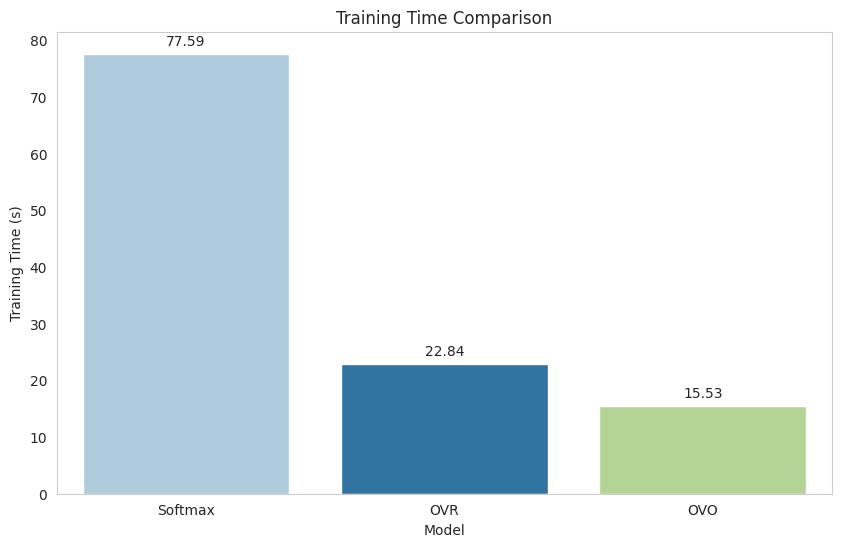

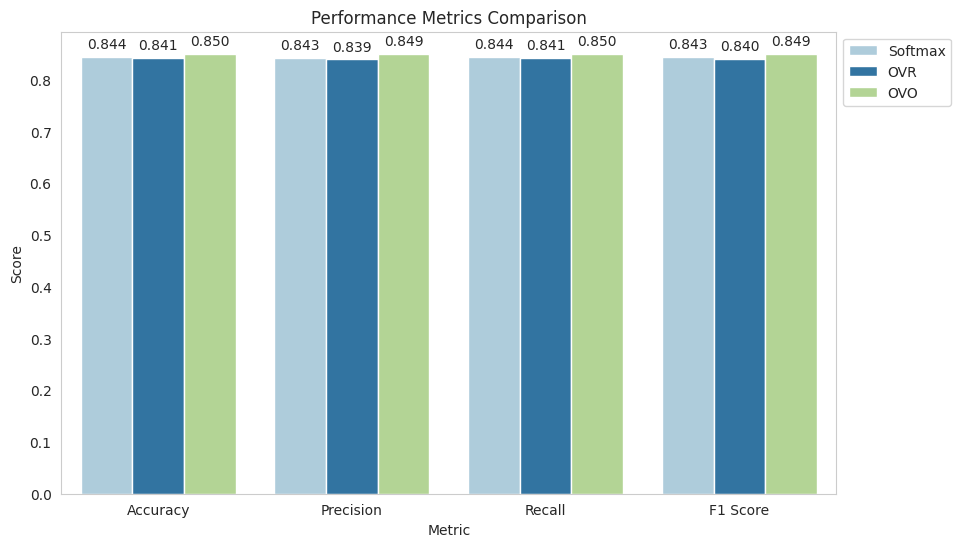

In [ ]:
custom_palette = sns.color_palette("Paired", as_cmap=False)  # "viridis" is a gradient palette
sns.set_palette(custom_palette)

# Plotting training time comparison
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Training Time (s)', data=LR_df)
plt.title('Training Time Comparison')

# Display values ​​on columns
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')
plt.show()

# Plotting performance metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
df_melted = LR_df.melt(id_vars=['Model'], value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted)
plt.title('Performance Metrics Comparison')

# Display values ​​on columns
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

* OVO is clearly the most effective model in terms of both training time and performance metrics (accuracy, precision, recall, F1 score).

* Softmax has the longest training time, but its performance results are not significantly better than OVO.

* OVR, while having faster training time than Softmax, is still less effective than OVO in terms of performance metrics.

> **Based on these results, OVO seems to be the best choice for your classification task, as it optimizes both model training time and performance.**


---



## **Support Vector Machine (SVM)**

### **Paramater**

**`penalty: {‘l1’, ‘l2’} (default = ‘l2’)`**
> The regularization term of the target function.

**`loss:{‘squared_hinge’, ‘hinge’} (default = ‘squared_hinge’)`**
> The loss term of the target function.

**`fit_intercept: bool (default = True)`**
> Whether to fit the bias term. Set to False if you expect that the data is already centered.

**`penalized_intercept: bool (default = False)`**
> When true, the bias term is treated the same way as other features; i.e. it’s penalized by the regularization term of the target function. Enabling this feature forces an extra copying the input data X.

**`max_iter: int (default = 1000)`**
> Maximum number of iterations for the underlying solver.

**`linesearch_max_iter: int (default = 100)`**
> Maximum number of linesearch (inner loop) iterations for the underlying (QN) solver.

**`lbfgs_memory: int (default = 5)`**
>Number of vectors approximating the hessian for the underlying QN solver (l-bfgs).

**`C: float (default = 1.0)`**
> The constant scaling factor of the loss term in the target formula:  
$
F(X, y) = \text{penalty}(X) + C \times \text{loss}(X, y)
$

> $C$ is a parameter that adjusts the model's strictness regarding misclassified data points.

> $C$ balances the trade-off between the model's accuracy on the training set and its ability to generalize.

**Gamma (RBF kernel):**
> Affects how data points influence each other in the feature space.

> Gamma adjusts the complexity of the decision boundary in the feature space.


---



### **Linear Kernel**

In [ ]:
# Training SVM witth linear kernel model
svc_linear_model = LinearSVC(C=0.1) # with C = 0.1, model has the best performance

start_time = time.time()
svc_linear_model.fit(train_images, train_labels)
end_time = time.time()

# Calculate training time
svc_linear_training_time = end_time - start_time

Training time: 3.85s
Accuracy: 0.8417
Precision: 0.8390
Recall: 0.8417
F1 Score: 0.8392


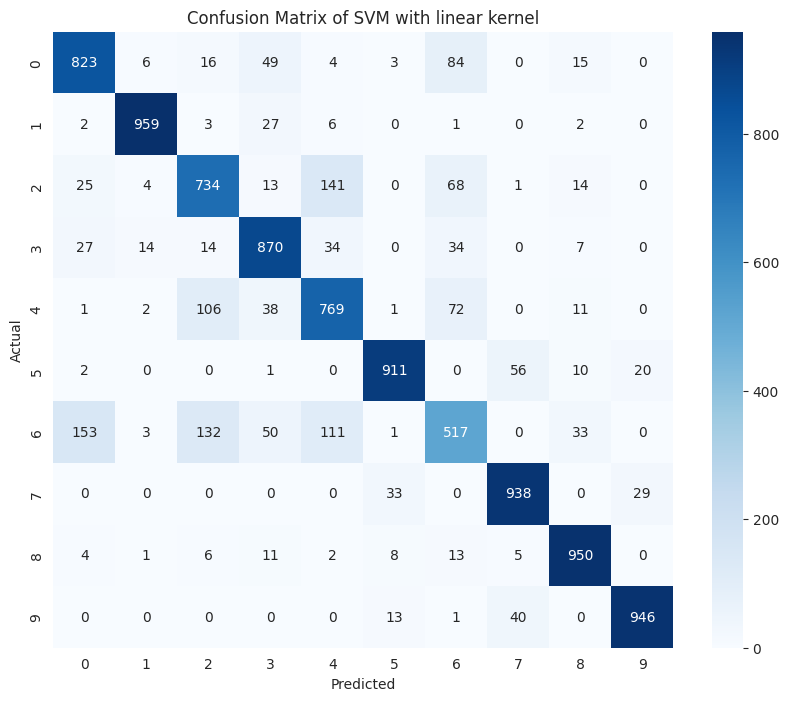

In [ ]:
# Make predictions
test_predictions = svc_linear_model.predict(test_images)
pred_svc_linear = test_predictions

# Evaluate Support Vector Machine model with linear kernel
svc_linear_accuracy = accuracy_score(test_labels, test_predictions)
svc_linear_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_linear_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_linear_f1 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')

print(f"Training time: {svc_linear_training_time:.2f}s")
print(f"Accuracy: {svc_linear_accuracy:.4f}")
print(f"Precision: {svc_linear_precision:.4f}")
print(f"Recall: {svc_linear_recall:.4f}")
print(f"F1 Score: {svc_linear_f1:.4f}")

test_predictions = test_predictions.astype('int32')
# Confusion Matrix
svc_linear_conf_matrix = confusion_matrix(test_labels, test_predictions)
svc_linear_conf_matrix = cp.asnumpy(svc_linear_conf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(svc_linear_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of SVM with linear kernel')
plt.show()

#### **Observation from Score**

* **Accuracy:** The model achieves an accuracy of 84.20%, indicating it correctly predicts 84.20% of the samples in the test set, which shows solid classification performance.

* **Precision:** The precision is 83.94%, meaning 83.94% of the model's positive predictions are correct.

* **Recall:** The recall is 84.20%, showing that the model correctly identifies 84.20% of the actual positive samples among all positive samples.

* **F1 Score:** The F1 Score is 83.96%, demonstrating a balanced performance between precision and recall, suggesting the model performs well across both metrics.


---



#### **Observation from Confusion Matrix**

In [ ]:
# Filter and print classes with correctly classified samples >= 900
for class_idx in range(svc_linear_conf_matrix.shape[0]):
    correct_predictions = svc_linear_conf_matrix[class_idx, class_idx]
    if correct_predictions >= 900:
        print(f"Class '{class_names[class_idx]}' has {correct_predictions} correctly classified samples.")

Class 'Trouser' has 959 correctly classified samples.
Class 'Sandal' has 911 correctly classified samples.
Class 'Sneaker' has 938 correctly classified samples.
Class 'Bag' has 950 correctly classified samples.
Class 'Ankle boot' has 946 correctly classified samples.


> Class **'Trouser', 'Sandal', 'Sneaker', 'Bag', 'Ankle'** have high accuracy with over 900 correct predictions and minimal misclassifications.


---



In [ ]:
# Filter and print class pairs with more than 100 misclassified samples, using class names
for actual_class in range(svc_linear_conf_matrix.shape[0]):
    for predicted_class in range(svc_linear_conf_matrix.shape[1]):
        if actual_class != predicted_class and svc_linear_conf_matrix[actual_class, predicted_class] > 100:
            print(f"Actual class '{class_names[actual_class]}' misclassified as '{class_names[predicted_class]}': {svc_linear_conf_matrix[actual_class, predicted_class]} samples")

Actual class 'Pullover' misclassified as 'Coat': 141 samples
Actual class 'Coat' misclassified as 'Pullover': 106 samples
Actual class 'Shirt' misclassified as 'T-shirt/top': 153 samples
Actual class 'Shirt' misclassified as 'Pullover': 132 samples
Actual class 'Shirt' misclassified as 'Coat': 111 samples


**There are 4 pairs of classes that are easily confused:**
* 'Pullover' vs 'Coat'
* 'Shirt' vs 'Coat'
* 'Shirt' vs 'Pullover'
* 'Shirt' vs 'T-shirt/top'


---



### **RBF kernel**

In [ ]:
# Training SVM with RBF model
svc_RBF_model = SVC(kernel='rbf', gamma='scale', C=10) # with gamma = 'scale', C = 10, model has the best performance

start_time = time.time()
svc_RBF_model.fit(train_images, train_labels)
end_time = time.time()

# Time for training model
svc_RBF_training_time = end_time - start_time

Training time: 22.45s
Accuracy: 0.9015
Precision: 0.9014
Recall: 0.9015
F1 Score: 0.9014


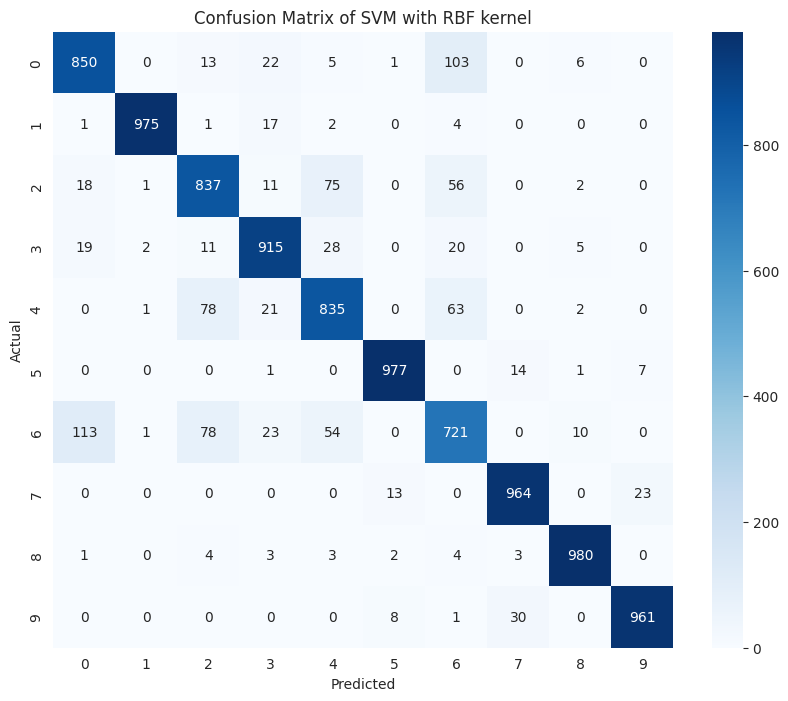

In [ ]:
# Make predictions on test set
test_predictions = svc_RBF_model.predict(test_images)
pred_svc_rbf = test_predictions

# Evaluate Support Vector Machine model with rbf kernel
svc_RBF_accuracy = accuracy_score(test_labels, test_predictions)
svc_RBF_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_RBF_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_RBF_f1 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')

print(f"Training time: {svc_RBF_training_time:.2f}s")
print(f"Accuracy: {svc_RBF_accuracy:.4f}")
print(f"Precision: {svc_RBF_precision:.4f}")
print(f"Recall: {svc_RBF_recall:.4f}")
print(f"F1 Score: {svc_RBF_f1:.4f}")

# Confusion Matrix
svc_RBF_conf_matrix = confusion_matrix(test_labels, test_predictions)
svc_RBF_conf_matrix = cp.asnumpy(svc_RBF_conf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(svc_RBF_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of SVM with RBF kernel')
plt.show()

#### **Observation from Score**

* **Accuracy:**  An accuracy of 90.15% means the model correctly predicts 90.15% of the test samples. This is an excellent result, especially if the data is not imbalanced or has rare classes. The model demonstrates outstanding performance and high classification accuracy.

* **Precision:** With a precision of 90.14%, 90.14% of the samples predicted as positive are actually positive (true positive + false positive). This indicates the model has an excellent ability to distinguish between classes and has a low false positive rate. Maintaining this level of precision is a positive sign of the model's effectiveness.

* **Recall:** The recall rate is 90.15%, meaning the model correctly identifies 90.15% of the actual positive samples (true positive + false negative). This shows that the model is not only accurate but also highly effective at detecting positive samples, minimizing the number of true positives that are missed. This is a commendable achievement.

* **F1 Score:** An F1 Score of 90.14%, the harmonic mean of Precision and Recall, indicates an excellent balance between these two metrics. A high F1 Score demonstrates that the model not only achieves high accuracy but also has a consistent ability to detect and classify positive samples. This is especially important in real-world applications where both precision and recall are crucial.


---



#### **Observation from Confusion Matrix**

In [ ]:
# Filter and print classes with correctly classified samples >= 900
for class_idx in range(svc_RBF_conf_matrix.shape[0]):
    correct_predictions = svc_RBF_conf_matrix[class_idx, class_idx]
    if correct_predictions >= 900:
        print(f"Class '{class_names[class_idx]}' has {correct_predictions} correctly classified samples.")

Class 'Trouser' has 975 correctly classified samples.
Class 'Dress' has 915 correctly classified samples.
Class 'Sandal' has 977 correctly classified samples.
Class 'Sneaker' has 964 correctly classified samples.
Class 'Bag' has 980 correctly classified samples.
Class 'Ankle boot' has 961 correctly classified samples.


> Class **'Trouser', 'Dress', 'Sandal', 'Sneaker', 'Bag', 'Ankle'** have high accuracy with over 900 correct predictions and minimal misclassifications. Notably, the inclusion of **'Dress'** shows improved performance compared to other models, indicating that the model is effectively distinguishing this class as well.


---



In [ ]:
# Filter and print class pairs with more than 100 misclassified samples, using class names
for actual_class in range(svc_RBF_conf_matrix.shape[0]):
    for predicted_class in range(svc_RBF_conf_matrix.shape[1]):
        if actual_class != predicted_class and svc_RBF_conf_matrix[actual_class, predicted_class] > 100:
            print(f"Actual class '{class_names[actual_class]}' misclassified as '{class_names[predicted_class]}': {svc_RBF_conf_matrix[actual_class, predicted_class]} samples")

Actual class 'T-shirt/top' misclassified as 'Shirt': 103 samples
Actual class 'Shirt' misclassified as 'T-shirt/top': 113 samples


> **There is only 1 pairs of classes that are easily confused:** 'T-shirt/top' vs 'Shirt'


---



In [ ]:
# Creating a dataframe with the results
data = {
    'Kernel': ['Linear', 'RBF'],
    'Training Time (s)': [svc_linear_training_time, svc_RBF_training_time],
    'Accuracy': [svc_linear_accuracy, svc_RBF_accuracy],
    'Precision': [svc_linear_precision, svc_RBF_precision],
    'Recall': [svc_linear_recall, svc_RBF_recall],
    'F1 Score': [svc_linear_f1, svc_RBF_f1]
}
SVM_df = pd.DataFrame(data)

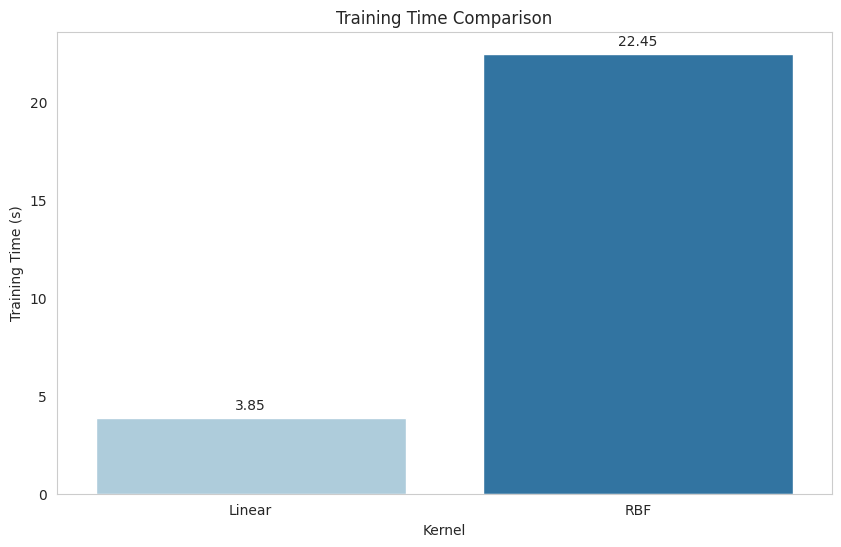

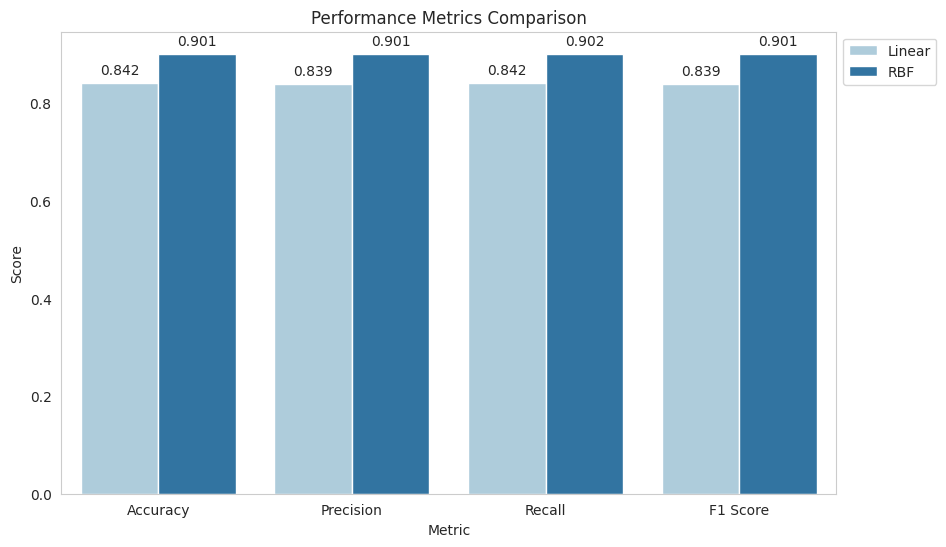

In [ ]:
custom_palette = sns.color_palette("Paired", as_cmap=False)  # "viridis" is a gradient palette
sns.set_palette(custom_palette)

# Plotting training time comparison
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Kernel', y='Training Time (s)', data=SVM_df)
plt.title('Training Time Comparison')

# Display values ​​on columns
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')
plt.show()

# Plotting performance metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
df_melted = SVM_df.melt(id_vars=['Kernel'], value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Metric', y='Score', hue='Kernel', data=df_melted)
plt.title('Performance Metrics Comparison')

# Display values ​​on columns
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

> **The Linear Kernel has a much faster training time compared to the RBF kernel. This may be because the linear kernel only needs to compute a linear separating boundary between classes, whereas the RBF kernel performs nonlinear computations to separate more complex data classes.**

> **The metrics for the RBF kernel are all higher than those for the linear kernel, indicating that the RBF kernel has better classification performance and is more effective at handling complex patterns. We can see that the RBF kernel performs better across all metrics (accuracy, precision, recall, F1 score), making it suitable for applications requiring higher accuracy.**


---



# **Model evaluation**

In [ ]:
data = {
    'Model': ['Softmax', 'OVR', 'OVO', 'Linear kernel SVM', 'RBF kernel SVM'],
    'Training Time (s)': [softmax_training_time, ovr_training_time, ovo_training_time, svc_linear_training_time, svc_RBF_training_time, ],
    'Accuracy': [softmax_accuracy, ovr_accuracy, ovo_accuracy,svc_linear_accuracy, svc_RBF_accuracy ],
    'Precision': [softmax_precision, ovr_precision, ovo_precision,svc_linear_precision, svc_RBF_precision ],
    'Recall': [softmax_recall, ovr_recall, ovo_recall,svc_linear_recall, svc_RBF_recall ],
    'F1 Score': [softmax_f1, ovr_f1_score, ovo_f1_score, svc_linear_f1, svc_RBF_f1]
}
all_model_df = pd.DataFrame(data)

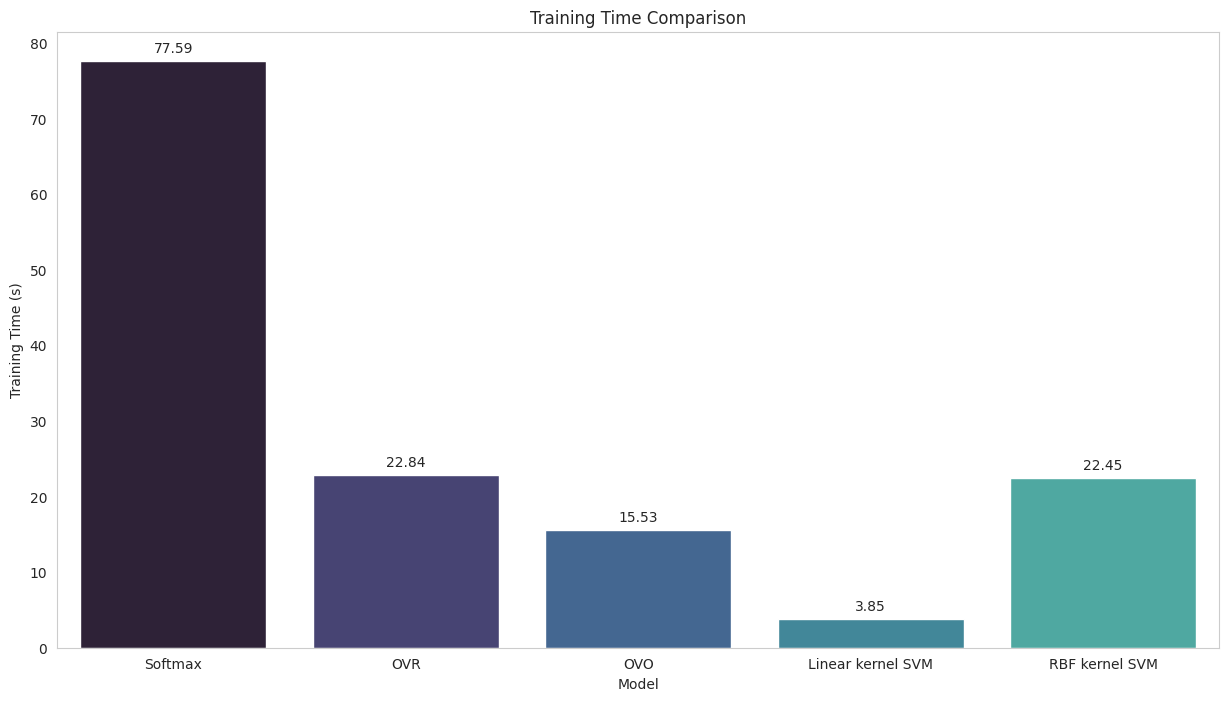

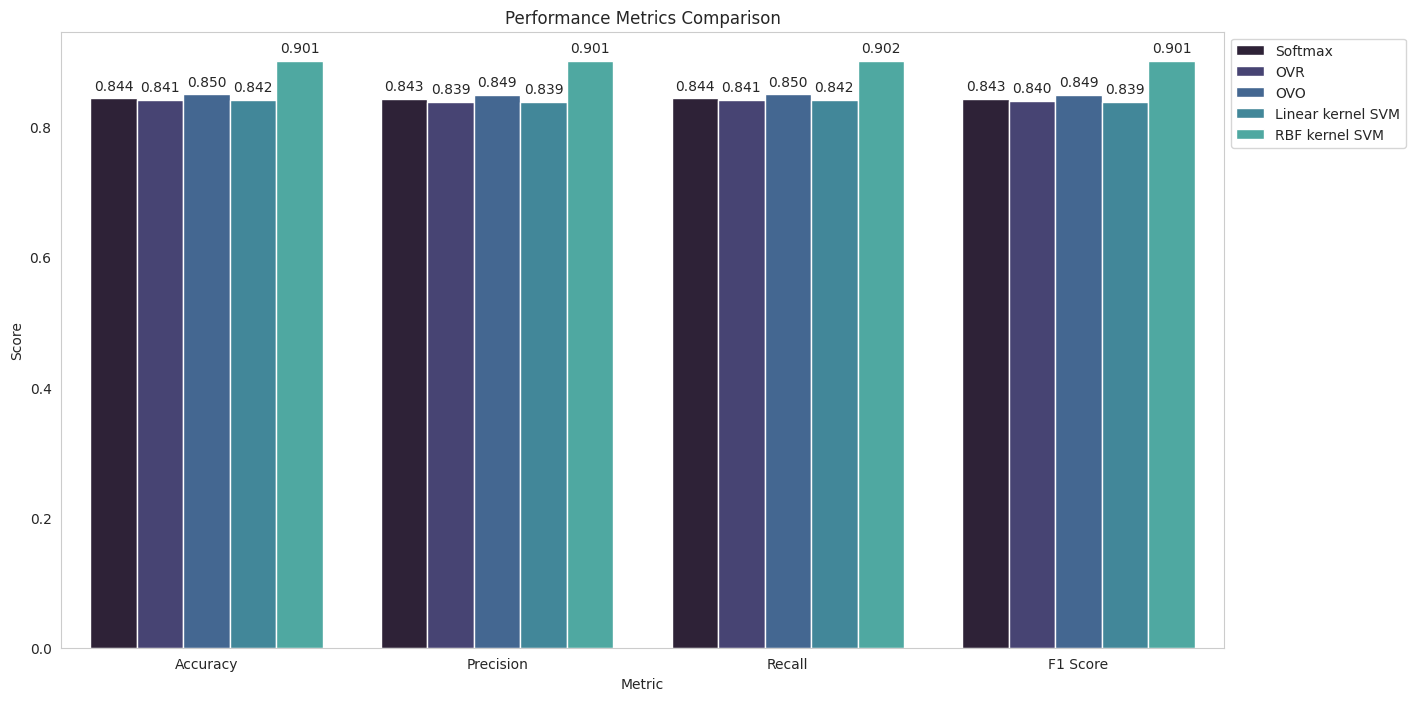

In [ ]:
custom_palette = sns.color_palette("mako", as_cmap=False)  # "viridis" is a gradient palette
sns.set_palette(custom_palette)

# Plotting training time comparison
plt.figure(figsize=(15, 8))
ax = sns.barplot(x='Model', y='Training Time (s)', data=all_model_df)
plt.title('Training Time Comparison')

# Display values ​​on columns
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')
plt.show()

# Plotting performance metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
df_melted = all_model_df.melt(id_vars=['Model'], value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(15, 8))
ax = sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted)
plt.title('Performance Metrics Comparison')

# Display values ​​on columns
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

**Observations and Evaluation**
> **In terms of runtime, the linear kernel SVM model is much faster than the other models (3.77s). However, its accuracy is almost similar and does not show significant improvement compared to other models (around 84%).**

> **According to the evaluation scores, the RBF model shows a substantial accuracy improvement over the other models (at 90.1%). Although its runtime is considerably higher than linear SVM, it is still at an acceptable level.**

> **The Logistic Regression models (OvO and OvR) produce fairly good results, with accuracies of 85% and 84%, respectively. The OvO model has a shorter runtime due to parallel optimization on the GPU.**

> **Softmax yields results similar to those of the OvO, OvR, and linear kernel SVM models. However, its runtime is significantly longer compared to the average of other models (67.12s), consuming substantial resources even when run on a GPU.**


---



### Visually the Images in Class Pairs are easily confused

In [ ]:
data = {'Softmax': pred_softmax.get(), 'OVR': pred_ovr.get(), 'OVO': pred_ovo.get(), 'Linear kernel': pred_svc_linear.get().astype('int32'), 'RBF kernel': pred_svc_rbf.get(), 'Test label': test_labels.get() }

In [ ]:
df = pd.DataFrame(data)
df

,Softmax,OVR,OVO,Linear kernel,RBF kernel,Test label
0,9,9,9,9,9,9
1,2,2,2,2,2,2
2,1,1,1,1,1,1
3,1,1,1,1,1,1
4,6,6,6,6,6,6
...,...,...,...,...,...,...
9995,9,9,9,9,9,9
9996,1,1,1,1,1,1
9997,6,6,6,8,8,8
9998,1,1,1,1,1,1


> **The SVC model with the RBF kernel has a high accuracy (greater than 90%). There is only one pair of classes that are easily confused in this model, which is 'T-shirt/top' vs 'Shirt'. Therefore, we will only implement it on the remaining models (since the easily confused pairs in the other models also include 'T-shirt/top' vs 'Shirt')**


---



In [ ]:
df = df.drop('RBF kernel', axis=1)

**Class pairs that are easily confused:**
* 'Pullover' vs 'Coat' : 2 vs 4
* 'Shirt' vs 'Coat': 6 vs 4
* 'Shirt' vs 'Pullover': 6 vs 2
* 'Shirt' vs 'T-shirt/top': 6 vs 0


---




In [ ]:
filtered_df1 = df[(df.iloc[:, :4].eq(2).sum(axis=1) >= 3) & (df['Test label'] == 4)]
filtered_df2 = df[(df.iloc[:, :4].eq(4).sum(axis=1) >= 3) & (df['Test label'] == 2)]

In [ ]:
def showImageClass(df1, df2,  df=test_images.get(), n=5):
    plt.figure(figsize=(10, 10), dpi=150)
    # Get n random indices from df1
    random_indices = np.random.choice(df1.index, n, replace=False)
    random_indices_df2 = np.random.choice(df2.index, n, replace=False)

    for i in range(n):
        plt.subplot(1, n, i + 1)
        index = random_indices[i]
        image_data = df[index].reshape(28, 28)
        plt.imshow(image_data, cmap='gray')
        plt.xticks([])
        plt.yticks([])
    plt.show()
    plt.figure(figsize=(10, 10), dpi=150)
    for i in range(n):
        plt.subplot(2, n, i + 1 + n)
        index2 = random_indices_df2[i]
        image_data2 = df[index2].reshape(28, 28)
        plt.imshow(image_data2, cmap='gray')
        plt.xticks([])
        plt.yticks([])
    plt.show()

#### **'Coat' vs 'Pullover'**

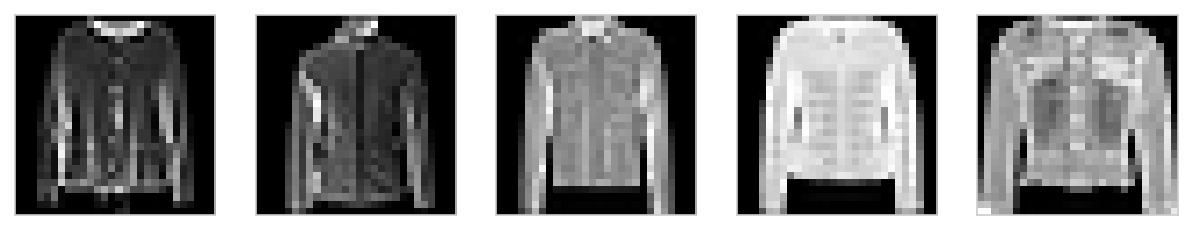

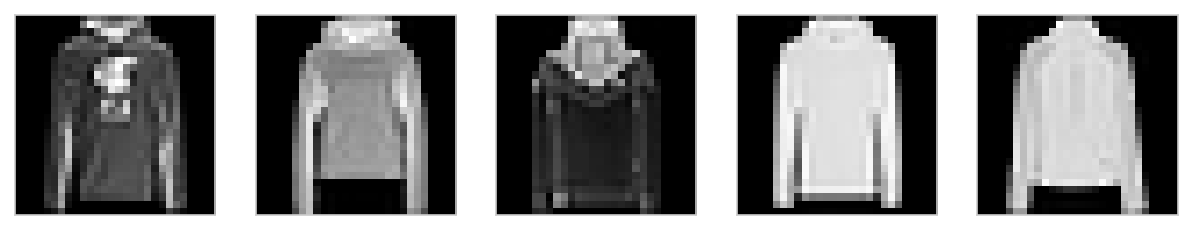

In [ ]:
showImageClass(filtered_df1,filtered_df2)

#### **'Coat' vs 'Shirt'**

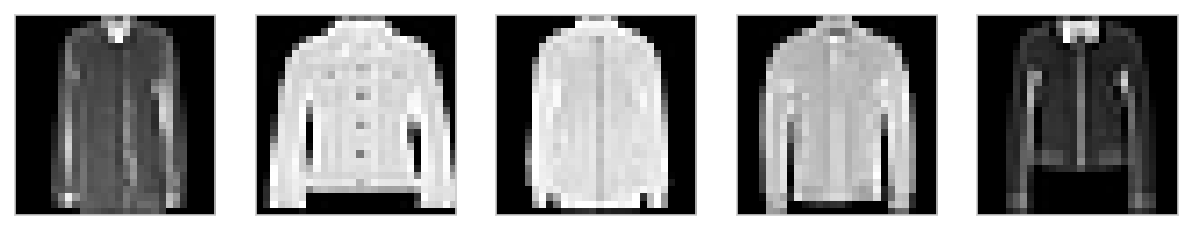

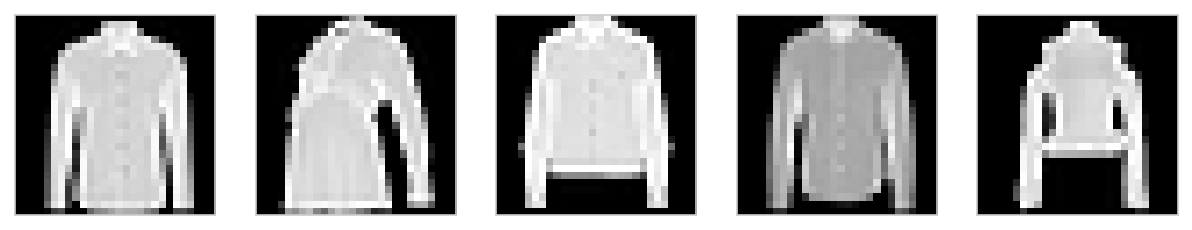

In [ ]:
filtered_df1 = df[(df.iloc[:, :4].eq(6).sum(axis=1) >= 3) & (df['Test label'] == 4)]
filtered_df2 = df[(df.iloc[:, :4].eq(4).sum(axis=1) >= 3) & (df['Test label'] == 6)]
showImageClass(filtered_df1,filtered_df2)

#### **'Pullover' vs 'Shirt'**

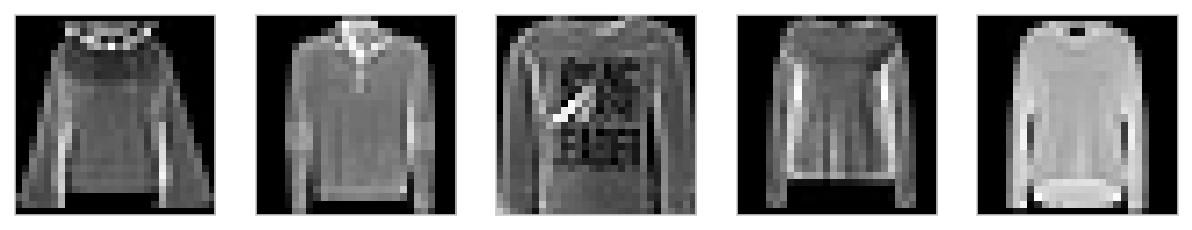

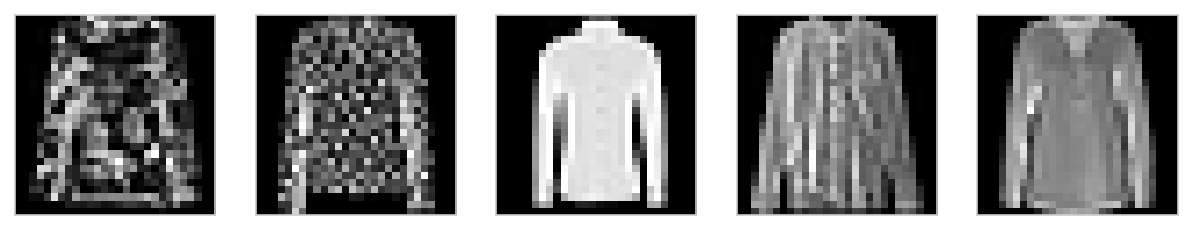

In [ ]:
filtered_df1 = df[(df.iloc[:, :4].eq(6).sum(axis=1) >= 3) & (df['Test label'] == 2)]
filtered_df2 = df[(df.iloc[:, :4].eq(2).sum(axis=1) >= 3) & (df['Test label'] == 6)]
showImageClass(filtered_df1,filtered_df2)

#### **'T-shirt/top' vs 'Shirt'**

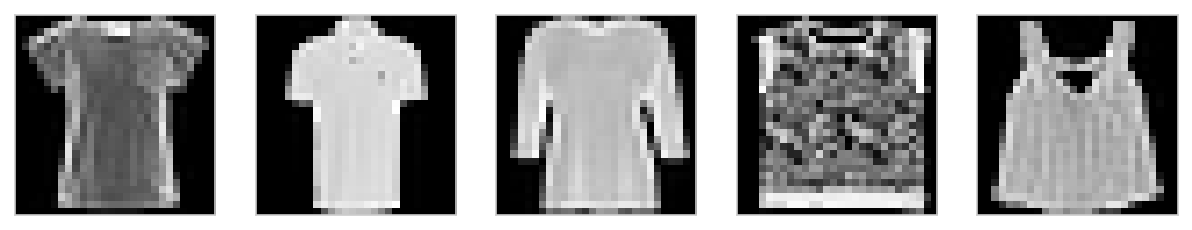

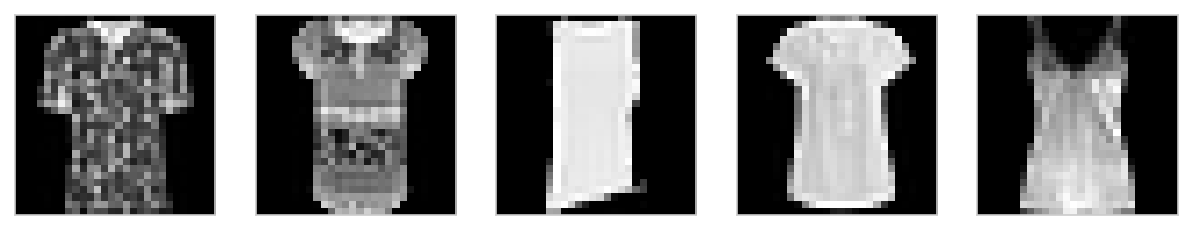

In [ ]:
filtered_df1 = df[(df.iloc[:, :4].eq(6).sum(axis=1) >= 3) & (df['Test label'] == 0)]
filtered_df2 = df[(df.iloc[:, :4].eq(0).sum(axis=1) >= 3) & (df['Test label'] == 6)]
showImageClass(filtered_df1,filtered_df2)

> **Based on the visual representations of the images that were misclassified between the classes, we can see a significant similarity in shape. As for the color, since the data consists of black-and-white images, there is a higher chance of similarity among them. Therefore, these models are likely to confuse the classes (the images were randomly selected from the misclassifications of the models).**


---



# **DIMENTIONALITY**

## **PCA**

### **Experiment with 2 principal components**

In [ ]:
from cuml.decomposition import PCA

In [ ]:
pca_2 = PCA(n_components = 2)
X_r = pca_2.fit_transform(train_images)

In [ ]:
pc2_array = np.concatenate([X_r, train_labels.reshape(-1, 1)], axis=1)

In [ ]:
pc2_df = pd.DataFrame(pc2_array.get(), columns=['PC1', 'PC2', 'Label'])
pc2_df['Label'] = pc2_df['Label'].astype(int)

<Axes: xlabel='PC1', ylabel='PC2'>

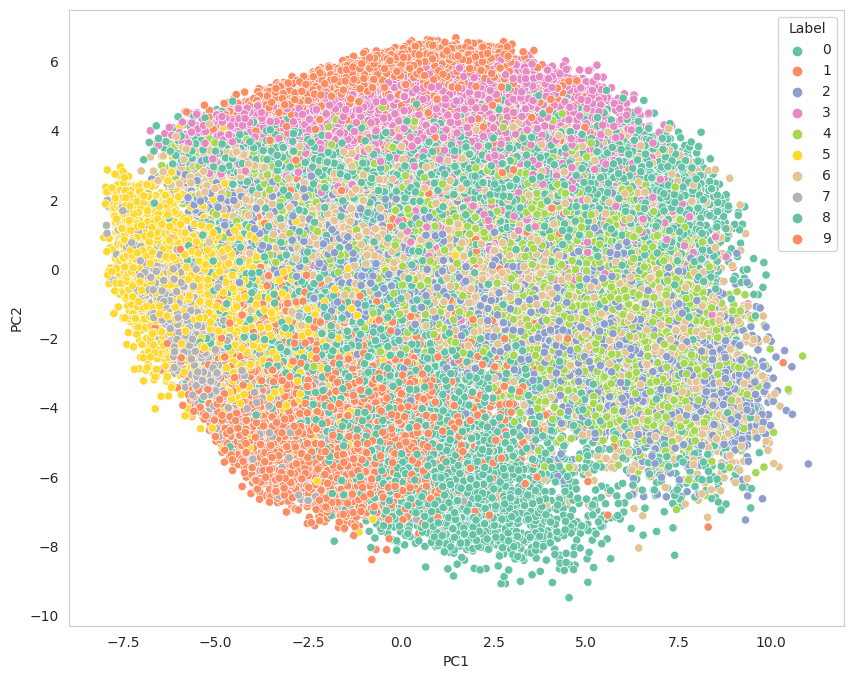

In [ ]:
#plotting dataset into 2d graph
plt.figure(figsize = (10,8))
sns.scatterplot(
    x = "PC1", y = "PC2",
    hue = "Label",
    palette = sns.mpl_palette("Set2", 10),
    data = pc2_df,
    legend = "full",
    alpha = 1.0,
)

The chart above shows a 2D projection of the fashion-MNIST dataset onto its two principal components using Principal Component Analysis (PCA). Here are some general observations:

> 1. **Data Spread:** The data points are widely spread across the PCA1 and PCA2 axes, indicating substantial variability in the feature space of the fashion-MNIST dataset.
2. **Clusters Corresponding to Labels:** Each color in the chart represents a different label in the dataset (from 0 to 9, corresponding to different types of clothing). Some labels tend to form clusters, but there is still significant overlap between labels. This suggests that PCA does not completely separate the clothing types in the 2D principal component space.
3. **Overlap Between Labels:** Some labels have overlapping clusters, such as label 1 (possibly shoes) and label 9 (possibly boots), which may share similar features, leading to overlap. This indicates that there are similarities in the shape or style of samples across different labels.
4. **Limited Separation Capability of PCA:** Since fashion-MNIST is a complex dataset with many clothing categories, dimensionality reduction using PCA only captures a small portion of the variance. To classify the labels more effectively, non-linear models or advanced dimensionality reduction techniques (such as t-SNE or UMAP) might provide better separation between the labels.


### **Exlanied variance**

In [ ]:
X_r = pca_2.fit(train_images).transform(train_images)
print(f'explained variance: {pca_2.explained_variance_ratio_}')

explained variance: [0.29031546 0.17751808]


**Explained Variance:** These values indicate the amount of information (or variance) that each component retains from the original data. The higher the explained variance, the more important the component is in representing the original data.
> * The first principal component accounts for 29.03% of the total variance in the data.
* The second principal component accounts for 17.75% of the total variance in data.

### **Visualize conponents vector**

**Original Image Size:** Our original images have a size of 28x28 pixels, meaning each image consists of 28×28=784 pixels.

> * When processed by machine learning algorithms or PCA, each image is typically converted into a vector with 784 elements, with each element representing one pixel.
* In PCA, each principal component is a vector with a length equal to the number of original features in the data, which is 784 elements in this case.

Text(0.5, 0.98, '2-Component PCA')

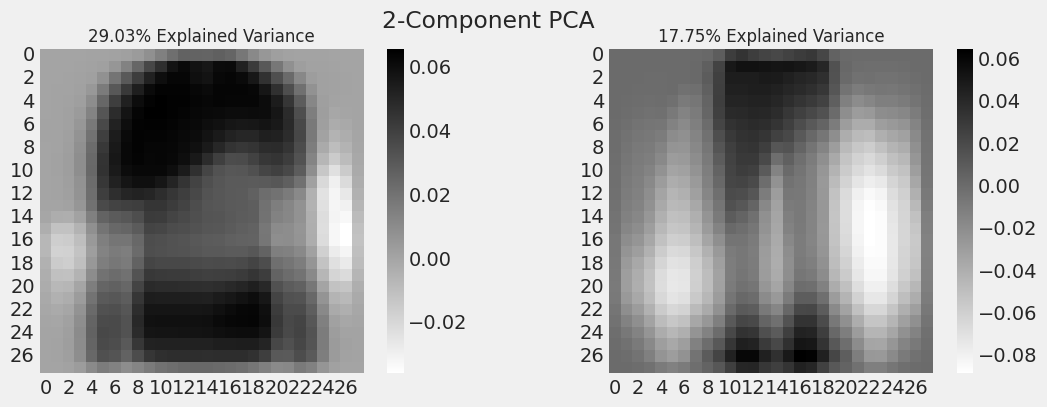

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

fig, axarr = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(pca_2.components_[0, :].get().reshape(28, 28), ax=axarr[0], cmap='gray_r')
sns.heatmap(pca_2.components_[1, :].get().reshape(28, 28), ax=axarr[1], cmap='gray_r')
axarr[0].set_title(
    "{0:.2f}% Explained Variance".format(pca_2.explained_variance_ratio_[0]*100),
    fontsize=12
)
axarr[1].set_title(
    "{0:.2f}% Explained Variance".format(pca_2.explained_variance_ratio_[1]*100),
    fontsize=12
)
axarr[0].set_aspect('equal')
axarr[1].set_aspect('equal')

plt.suptitle('2-Component PCA')

> This heatmap reveals the main features in the images that PCA detects, reflecting the directions in which the data changes the most in the original space (highest variance).

> In the MNIST Fashion dataset, these component vectors indicate which pixels exhibit the most variation. The value of each pixel in the components (reshaped into 28x28 to match the original image size) reflects the degree to which that pixel contributes to the overall variance of the dataset.

> Pixels with high values (positive or negative) correspond to bright and dark areas in the image, meaning they play a significant role in differentiating between the images in the dataset.


**Observation:**

> * In the heatmap of Component 1 (which explains the most information), we can see a faint image of shirts and shoes. This suggests that PC1 captures the most common variation pattern of fashion products in the MNIST Fashion dataset, particularly for shirts and shoes.
* The data tends to vary significantly in relation to shirts and shoes (many classes contain shirts and shoes) => **Models will likely find it easier to distinguish classes related to shirts and shoes.**
* Similarly, PC2 captures the common variation pattern of pants and shoes in the dataset.

In [ ]:
pca = PCA(n_components=784)
# Fit PCA on train_images and transform train_images
train_images_pca = pca.fit_transform(train_images)

In [ ]:
# Chuyển explained variance và cumulative explained variance từ GPU sang CPU để vẽ
explained_variance_ratio = cp.asnumpy(pca.explained_variance_ratio_)
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
step = 50
points = np.arange(1, len(cumulative_variance_ratio) + 1, step)
cumulative_variance_at_points = cumulative_variance_ratio[points - 1]

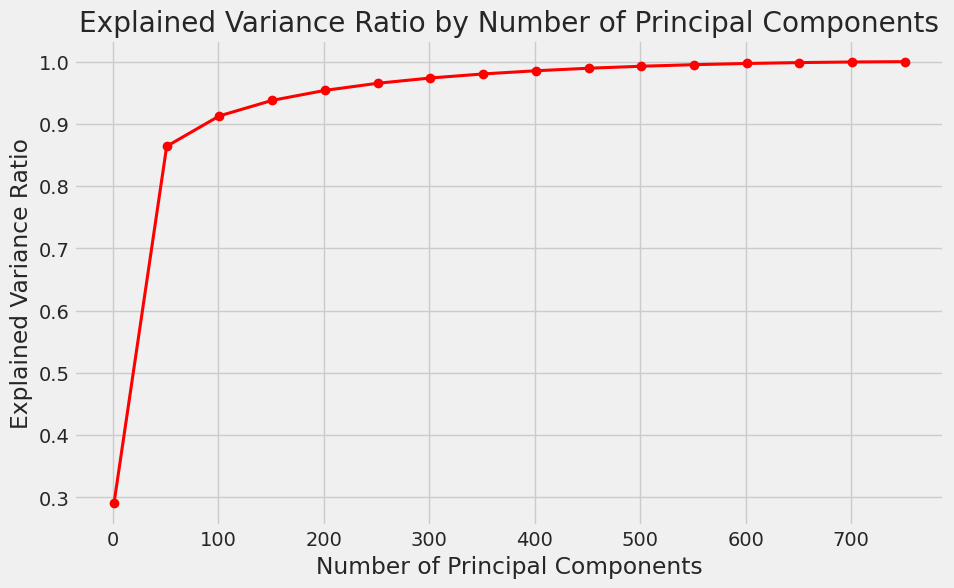

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(points, cumulative_variance_at_points, marker='o', linestyle='-', linewidth = 2.2, color = 'r')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by Number of Principal Components')
plt.grid(True)
plt.show()

> The plot shows the explained variance ratio of principal components, which increases rapidly at first, reaching nearly 90% with around the first 50 components. After that, the increase in explained variance slows down, and from 300 components onward, the change becomes minimal. This indicates that adding more components beyond a certain point doesn't provide much additional information.

> Therefore, **using around 200 components** might be sufficient to retain most of the variance in the data.

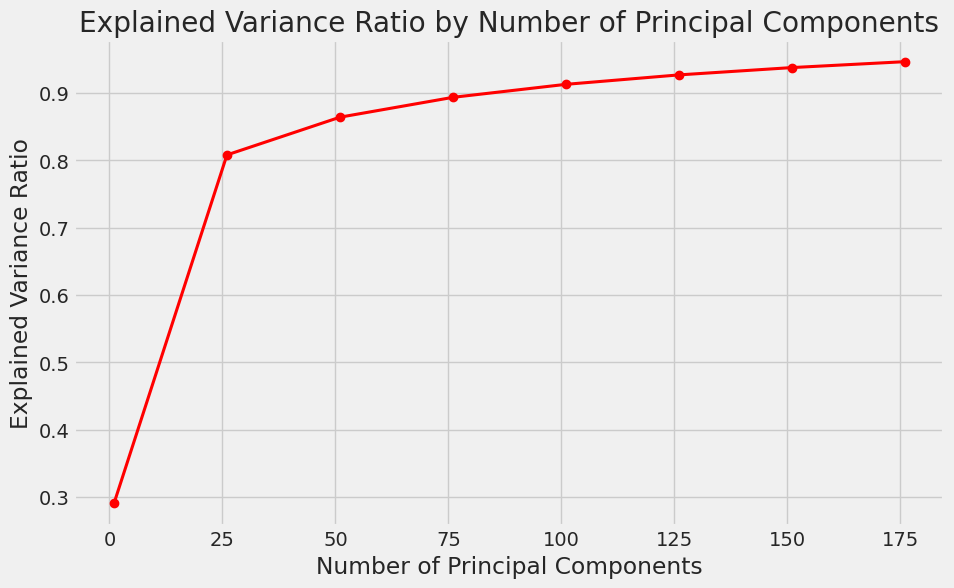

In [ ]:
pca = PCA(n_components=200)
# Fit PCA on train_images and transform train_images
train_images_pca = pca.fit_transform(train_images)

# Chuyển explained variance và cumulative explained variance từ GPU sang CPU để vẽ
explained_variance_ratio = cp.asnumpy(pca.explained_variance_ratio_)
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

step = 25
points = np.arange(1, len(cumulative_variance_ratio) + 1, step)
cumulative_variance_at_points = cumulative_variance_ratio[points - 1]

plt.figure(figsize=(10, 6))
plt.plot(points, cumulative_variance_at_points, marker='o', linestyle='-', linewidth = 2.2, color = 'r')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by Number of Principal Components')
plt.grid(True)
plt.show()

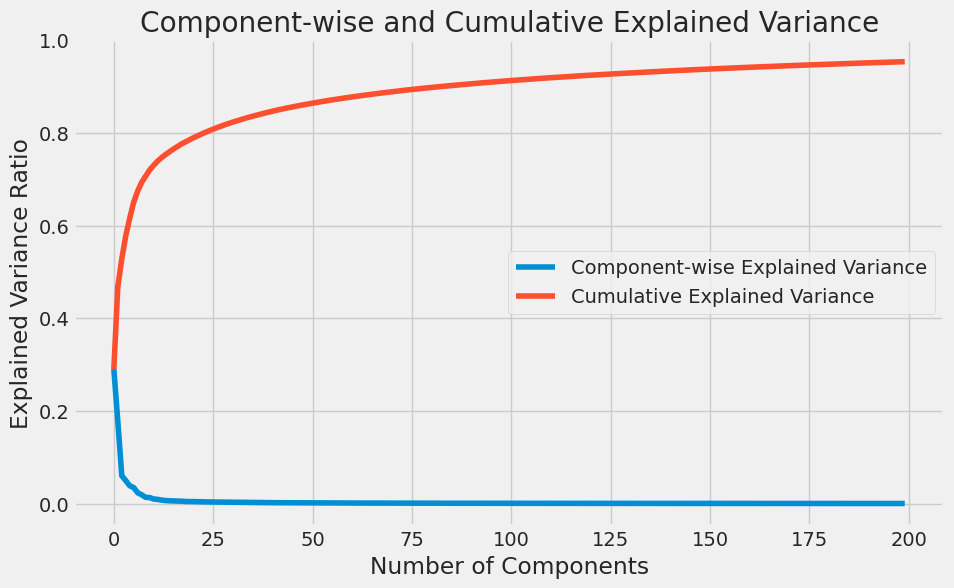

In [ ]:
# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(range(200), explained_variance_ratio, label="Component-wise Explained Variance")
plt.plot(range(200), cumulative_variance_ratio, label="Cumulative Explained Variance")
plt.title("Component-wise and Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.legend()
plt.show()

> This chart displays the component-wise explained variance and cumulative explained variance as the number of principal components increases. The blue line shows the explained variance ratio for each individual component, which drops sharply after the first few components.
* The red line represents cumulative variance, indicating that about `100 components` are sufficient to retain nearly all the information in the data.
* However, adding an additional `25 components` will allow for a more detailed analysis and could reveal clearer differences.

## **Apply PCA**

### **With n_components = 100**

In [ ]:
# Initialize PCA object
pca_100 = PCA(n_components = 100)

# Fit PCA on train_images and transform train_images
train_images_pca_100 = pca_100.fit_transform(train_images)

# Transform test_images using the same PCA model
test_images_pca_100 = pca_100.transform(test_images)

In [ ]:
# Training SVM witth linear kernel model
svc_linear_model_pca_100 = LinearSVC(C=0.1) # with C = 0.1, model has the best performance

start_time = time.time()
svc_linear_model_pca_100.fit(train_images_pca_100, train_labels)
end_time = time.time()

# Calculate training time
svc_linear_pca_100_training_time = end_time - start_time

In [ ]:
# Make predictions
test_predictions = svc_linear_model_pca_100.predict(test_images_pca_100)
pred_svc_linear_pca_100 = test_predictions

# Evaluate Support Vector Machine model with linear kernel
svc_linear_pca_100_accuracy = accuracy_score(test_labels, test_predictions)
svc_linear_pca_100_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_linear_pca_100_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_linear_pca_100_f1 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')

print(f"Training time: {svc_linear_pca_100_training_time:.2f}s")
print(f"Accuracy: {svc_linear_pca_100_accuracy:.4f}")
print(f"Precision: {svc_linear_pca_100_precision:.4f}")
print(f"Recall: {svc_linear_pca_100_recall:.4f}")
print(f"F1 Score: {svc_linear_pca_100_f1:.4f}")

Training time: 0.36s
Accuracy: 0.8340
Precision: 0.8310
Recall: 0.8340
F1 Score: 0.8314


In [ ]:
# Training SVM with RBF model
svc_RBF_pca_100_model = SVC(kernel='rbf', gamma='scale', C=10) # with gamma = 'scale', C = 10, model has the best performance

start_time = time.time()
svc_RBF_pca_100_model.fit(train_images_pca_100, train_labels)
end_time = time.time()

# Time for training model
svc_RBF_pca_100_training_time = end_time - start_time

In [ ]:
# Make predictions on test set
test_predictions = svc_RBF_pca_100_model.predict(test_images_pca_100)
pred_svc_rbf_pca_100 = test_predictions

# Evaluate Support Vector Machine model with rbf kernel
svc_RBF_pca_100_accuracy = accuracy_score(test_labels, test_predictions)
svc_RBF_pca_100_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_RBF_pca_100_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_RBF_pca_100_f1 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')

print(f"Training time: {svc_RBF_pca_100_training_time:.2f}s")
print(f"Accuracy: {svc_RBF_pca_100_accuracy:.4f}")
print(f"Precision: {svc_RBF_pca_100_precision:.4f}")
print(f"Recall: {svc_RBF_pca_100_recall:.4f}")
print(f"F1 Score: {svc_RBF_pca_100_f1:.4f}")

Training time: 9.37s
Accuracy: 0.8998
Precision: 0.8999
Recall: 0.8998
F1 Score: 0.8998


In [ ]:
ovo_pca_100_model=OneVsOneClassifier(cuMLLogisticRegression(max_iter=3000))

start=time.time()
ovo_pca_100_model.fit(train_images_pca_100, train_labels)
ovo_pca_100_training_time =time.time()-start

preds =ovo_pca_100_model.predict(test_images_pca_100)
pred_ovo_pca_100 = preds

ovo_pca_100_accuracy = accuracy_score(test_labels,preds)
ovo_pca_100_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovo_pca_100_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovo_pca_100_f1_score = f1_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')


print(f"Training time : {ovo_pca_100_training_time : .3f}")
print(f"Accuracy : {ovo_pca_100_accuracy}")
print(f"Precision score : {ovo_pca_100_precision:} " )
print(f"Recall score: {ovo_pca_100_recall}")
print(f"F1 score : {ovo_pca_100_f1_score} ")

Training time :  3.233
Accuracy : 0.8468999862670898
Precision score : 0.8455710229343945 
Recall score: 0.8469000000000001
F1 score : 0.8460542207433168 


In [ ]:
ovr_pca_100_model=OneVsRestClassifier(cuMLLogisticRegression(max_iter=3000))


start=time.time()
ovr_pca_100_model.fit(train_images_pca_100, train_labels)
ovr_pca_100_training_time =time.time()-start

preds = ovr_pca_100_model.predict(test_images_pca_100)
pred_ovr = preds

ovr_pca_100_accuracy = accuracy_score(test_labels,preds)
ovr_pca_100_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovr_pca_100_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovr_pca_100_f1_score = f1_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')


print(f"Training time : {ovr_pca_100_training_time : .3f}")
print(f"Accuracy : {ovr_pca_100_accuracy}")
print(f"Precision score : {ovr_pca_100_precision:} " )
print(f"Recall score: {ovr_pca_100_recall}")
print(f"F1 score : {ovr_pca_100_f1_score} ")

Training time :  2.047
Accuracy : 0.8378000259399414
Precision score : 0.8352925958304693 
Recall score: 0.8378
F1 score : 0.8358943513721797 


In [ ]:
# Train Logistic Regression with multiple-class after PCA (Softmax Regression)
softmax_pca_100_model = cuMLLogisticRegression(max_iter=3000, solver='qn', fit_intercept=True) # multiple-class (using softmax loss) variants, depending on the input variables

start_time = time.time()
softmax_pca_100_model.fit(train_images_pca_100, train_labels)
end_time = time.time()

# calculate training time
softmax_pca_100_training_time = end_time - start_time

# Make predict on test-set
test_predictions = softmax_pca_100_model.predict(test_images_pca_100)
pred_softmax = test_predictions

# Evaluate softmax Regression model
softmax_pca_100_accuracy = accuracy_score(test_labels, test_predictions)
softmax_pca_100_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
softmax_pca_100_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
softmax_pca_100_f1 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')

print(f"Training time: {softmax_pca_100_training_time:.2f}s")
print(f"Accuracy: {softmax_pca_100_accuracy:.4f}")
print(f"Precision: {softmax_pca_100_precision:.4f}")
print(f"Recall: {softmax_pca_100_recall:.4f}")
print(f"F1 Score: {softmax_pca_100_f1:.4f}")

Training time: 6.97s
Accuracy: 0.8407
Precision: 0.8389
Recall: 0.8407
F1 Score: 0.8395


### **Modelcompare & evaluation**

In [ ]:
data = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'Training Time (s)': [softmax_pca_100_training_time, ovr_pca_100_training_time, ovo_pca_100_training_time,svc_linear_pca_100_training_time,svc_RBF_pca_100_training_time],
    'Accuracy': [softmax_pca_100_accuracy, ovr_pca_100_accuracy, ovo_pca_100_accuracy,svc_linear_pca_100_accuracy,svc_RBF_pca_100_accuracy],
    'Precision': [softmax_pca_100_precision, ovr_pca_100_precision, ovo_pca_100_precision,svc_linear_pca_100_precision,svc_RBF_pca_100_precision],
    'Recall': [softmax_pca_100_recall, ovr_pca_100_recall, ovo_pca_100_recall, svc_linear_pca_100_recall, svc_RBF_pca_100_recall],
    'F1 Score': [softmax_pca_100_f1, ovr_pca_100_f1_score, ovo_pca_100_f1_score, svc_linear_pca_100_f1, svc_RBF_pca_100_f1]
}
model_df = pd.DataFrame(data)

In [ ]:
model_df

,Model,Training Time (s),Accuracy,Precision,Recall,F1 Score
0,Softmax,6.973803,0.8407,0.838950,0.8407,0.839537
1,OVR,2.046878,0.8378,0.835293,0.8378,0.835894
2,OVO,3.233223,0.8469,0.845571,0.8469,0.846054
3,SVM Linear,0.355185,0.8340,0.830960,0.8340,0.831414
4,SVM RBF,9.365080,0.8998,0.899943,0.8998,0.899770


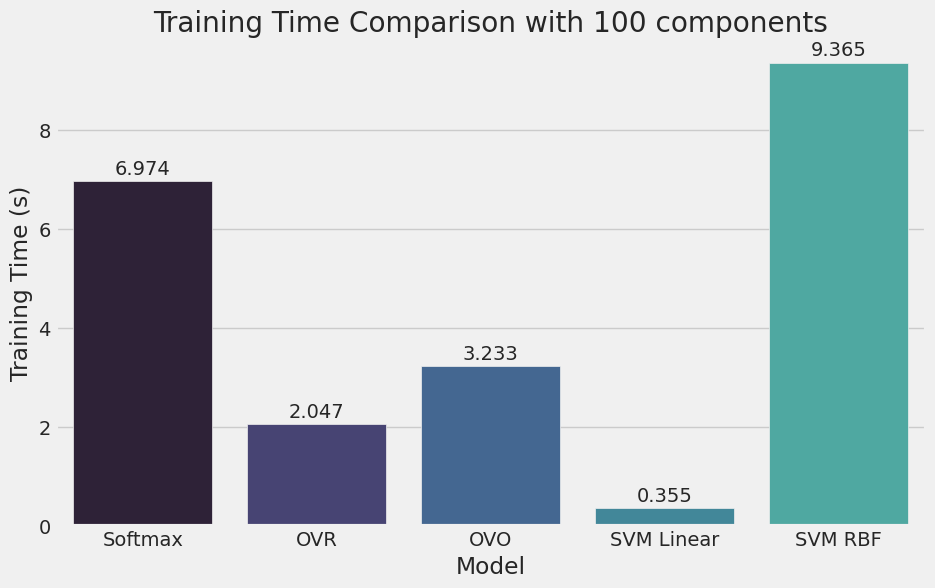

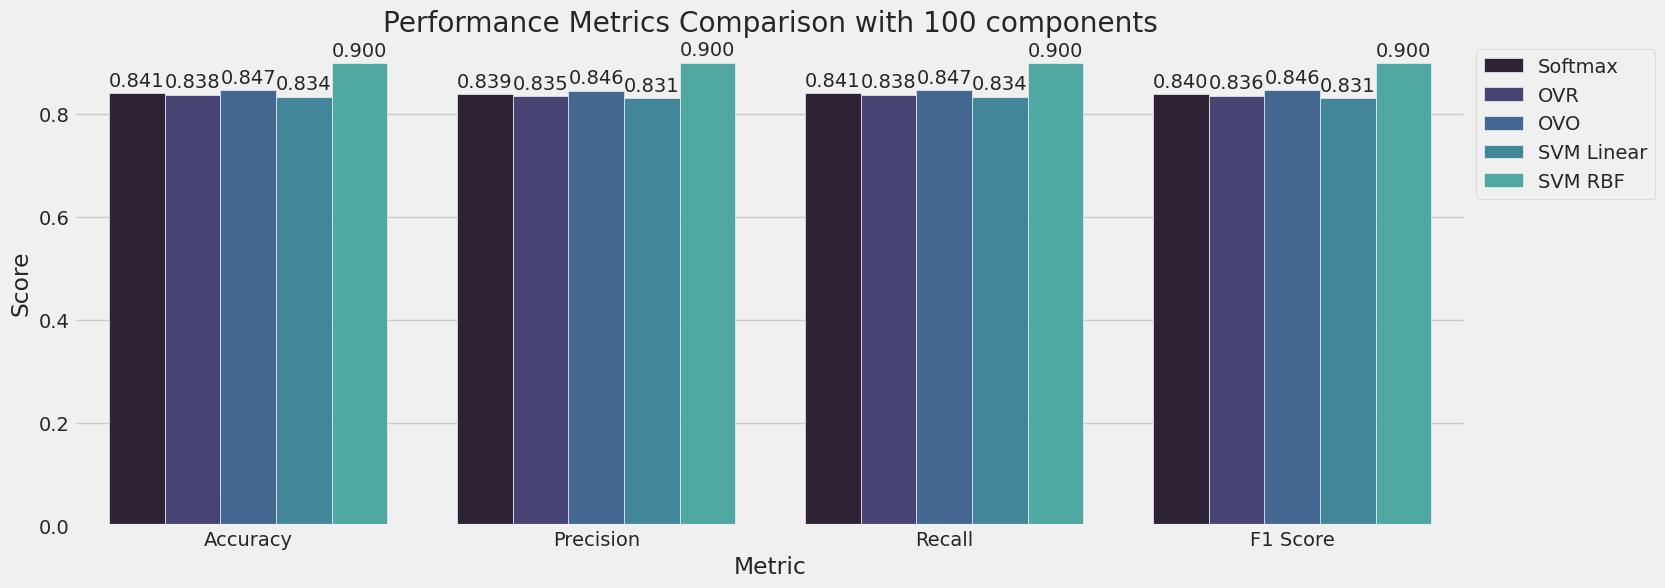

In [ ]:
custom_palette = sns.color_palette("mako", as_cmap=False)  # "viridis" is a gradient palette
sns.set_palette(custom_palette)

# Plotting training time comparison
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Training Time (s)', data=model_df)
plt.title('Training Time Comparison with 100 components')

# Hiển thị giá trị trên cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')
plt.show()

# Plotting performance metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
df_melted = model_df.melt(id_vars=['Model'], value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(16, 6))
ax = sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted)
plt.title('Performance Metrics Comparison with 100 components')

# Hiển thị giá trị trên cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()


In examining the training times and performance metrics of different models after reducing to 100 components, a few key insights emerge:

> 1. **Training Time (100 Components):**
* **SVM with Linear Kernel:** This model has the shortest training time (0.355 seconds), making it highly efficient for large datasets or applications requiring quick retraining. The linear kernel is often computationally cheaper because it involves simpler mathematical operations compared to other kernels like RBF.
* **OvR (One-vs-Rest):** At 2.047 seconds, the OvR approach is also relatively fast. This technique, which trains one classifier per class, is efficient in many cases but slightly slower than the SVM Linear kernel model.
* **OvO (One-vs-One):** With a training time of 3.233 seconds, OvO is moderately fast but slower than OvR. The OvO approach creates one classifier for every pair of classes, which can increase computational complexity, especially in multiclass problems.
* **Softmax:** While Softmax is no longer the slowest model (6.974 seconds), its training time remains considerable. This may be due to the iterative optimization process in logistic regression models, especially for multiclass classification.
* **SVM with RBF Kernel:** This model has the highest training time (9.365 seconds), primarily because the RBF kernel requires more computations as it maps inputs into higher-dimensional space. Although it can provide excellent accuracy, its computational demands can be a drawback in applications needing faster training.




> 2. **Performance Metrics (100 Components):**
Despite the reduction in dimensions to 100 components using PCA, there is almost no change in model performance. This suggests that PCA effectively captures the essential features in the data, reducing dimensionality without significant loss in predictive quality. Performance metrics are clustered around 0.83 to 0.90, indicating that all models maintain strong accuracy even after dimensionality reduction.


In [ ]:
TrainingTimes = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'Training Time before PCA (s)': [softmax_training_time, ovr_training_time, ovo_training_time,svc_linear_training_time,svc_RBF_training_time],
    'Training Time after PCA (s)': [softmax_pca_100_training_time, ovr_pca_100_training_time, ovo_pca_100_training_time,svc_linear_pca_100_training_time,svc_RBF_pca_100_training_time]
}
df_training_times_100 = pd.DataFrame(TrainingTimes)

Accuracy = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'Accuracy before PCA': [softmax_accuracy, ovr_accuracy, ovo_accuracy,svc_linear_accuracy,svc_RBF_accuracy],
    'Accuracy after PCA': [softmax_pca_100_accuracy, ovr_pca_100_accuracy, ovo_pca_100_accuracy,svc_linear_pca_100_accuracy,svc_RBF_pca_100_accuracy],
}
df_accuracy_100 = pd.DataFrame(Accuracy)

Precision = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'Precision before PCA': [softmax_precision, ovr_precision, ovo_precision,svc_linear_precision,svc_RBF_precision],
    'Precision after PCA': [softmax_pca_100_precision, ovr_pca_100_precision, ovo_pca_100_precision,svc_linear_pca_100_precision,svc_RBF_pca_100_precision],
}
df_precision_100 = pd.DataFrame(Precision)

Recall = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'Recall before PCA': [softmax_recall, ovr_recall, ovo_recall, svc_linear_recall, svc_RBF_recall],
    'Recall after PCA': [softmax_pca_100_recall, ovr_pca_100_recall, ovo_pca_100_recall, svc_linear_pca_100_recall, svc_RBF_pca_100_recall],
}
df_recall_100 = pd.DataFrame(Recall)

F1_Score = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'F1 Score before PCA': [softmax_f1, ovr_f1_score, ovo_f1_score, svc_linear_f1, svc_RBF_f1],
    'F1 Score after PCA': [softmax_pca_100_f1, ovr_pca_100_f1_score, ovo_pca_100_f1_score, svc_linear_pca_100_f1, svc_RBF_pca_100_f1]
}
df_f1_score_100 = pd.DataFrame(F1_Score)

In [ ]:
df_training_times_100

,Model,Training Time before PCA (s),Training Time after PCA (s)
0,Softmax,77.585387,6.973803
1,OVR,22.836686,2.046878
2,OVO,15.534057,3.233223
3,SVM Linear,3.850356,0.355185
4,SVM RBF,22.449022,9.365080



> The training time of all models is significantly reduced
* The training time of models such as `Softmax`, `OvR`, `SVM Linear` is reduced by about 10 times compared to before PCA
* `OvO` is reduced by about 4 times
* `SVM RBF` is reduced by about 2.5 times

In [ ]:
df_accuracy_100

,Model,Accuracy before PCA,Accuracy after PCA
0,Softmax,0.8440,0.8407
1,OVR,0.8413,0.8378
2,OVO,0.8502,0.8469
3,SVM Linear,0.8417,0.8340
4,SVM RBF,0.9015,0.8998


In [ ]:
df_precision_100

,Model,Precision before PCA,Precision after PCA
0,Softmax,0.842817,0.838950
1,OVR,0.839202,0.835293
2,OVO,0.848965,0.845571
3,SVM Linear,0.838955,0.830960
4,SVM RBF,0.901396,0.899943


In [ ]:
df_recall_100

,Model,Recall before PCA,Recall after PCA
0,Softmax,0.8440,0.8407
1,OVR,0.8413,0.8378
2,OVO,0.8502,0.8469
3,SVM Linear,0.8417,0.8340
4,SVM RBF,0.9015,0.8998


In [ ]:
df_f1_score_100

,Model,F1 Score before PCA,F1 Score after PCA
0,Softmax,0.843185,0.839537
1,OVR,0.839608,0.835894
2,OVO,0.849482,0.846054
3,SVM Linear,0.839245,0.831414
4,SVM RBF,0.901404,0.899770


> The model scores have decreased, but only very slightly, indicating that the initial dimensionality reduction has had a minimal impact on model performance.

> This suggests that the subsequent principal components in PCA contribute little to distinguishing the data, so retaining too many dimensions may not be necessary to maintain accuracy.

> Therefore, we could consider further reducing the dimensionality of the data to simplify the model, lower computational costs, and enhance generalization. Additional dimensionality reduction could help the model run faster and minimize the risk of overfitting, particularly with machine learning algorithms.

### **With n_components = 25**

In [ ]:
# Initialize PCA object
pca = PCA(n_components = 25)

# Fit PCA on train_images and transform train_images
train_images_pca_25 = pca.fit_transform(train_images)

# Transform test_images using the same PCA model
test_images_pca_25 = pca.transform(test_images)

In [ ]:
# Training SVM witth linear kernel model
svc_linear_model_pca_25 = LinearSVC(C=0.1) # with C = 0.1, model has the best performance

start_time = time.time()
svc_linear_model_pca_25.fit(train_images_pca_25, train_labels)
end_time = time.time()

# Calculate training time
svc_linear_pca_training_time_25 = end_time - start_time

In [ ]:
# Make predictions
test_predictions = svc_linear_model_pca_25.predict(test_images_pca_25)
pred_svc_linear_pca = test_predictions

# Evaluate Support Vector Machine model with linear kernel
svc_linear_pca_accuracy_25 = accuracy_score(test_labels, test_predictions)
svc_linear_pca_precision_25 = precision_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_linear_pca_recall_25 = recall_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_linear_pca_f1_25 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')

print(f"Training time: {svc_linear_pca_training_time_25:.2f}s")
print(f"Accuracy: {svc_linear_pca_accuracy_25:.4f}")
print(f"Precision: {svc_linear_pca_precision_25:.4f}")
print(f"Recall: {svc_linear_pca_recall_25:.4f}")
print(f"F1 Score: {svc_linear_pca_f1_25:.4f}")

Training time: 0.14s
Accuracy: 0.7905
Precision: 0.7832
Recall: 0.7905
F1 Score: 0.7824


In [ ]:
# Training SVM with RBF model
svc_RBF_pca_model_25 = SVC(kernel='rbf', gamma='scale', C=10) # with gamma = 'scale', C = 10, model has the best performance

start_time = time.time()
svc_RBF_pca_model_25.fit(train_images_pca_25, train_labels)
end_time = time.time()

# Time for training model
svc_RBF_pca_training_time_25 = end_time - start_time

In [ ]:
# Make predictions on test set
test_predictions = svc_RBF_pca_model_25.predict(test_images_pca_25)
pred_svc_rbf_pca = test_predictions

# Evaluate Support Vector Machine model with rbf kernel
svc_RBF_pca_accuracy_25 = accuracy_score(test_labels, test_predictions)
svc_RBF_pca_precision_25 = precision_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_RBF_pca_recall_25 = recall_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_RBF_pca_f1_25 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')

print(f"Training time: {svc_RBF_pca_training_time_25:.2f}s")
print(f"Accuracy: {svc_RBF_pca_accuracy_25:.4f}")
print(f"Precision: {svc_RBF_pca_precision_25:.4f}")
print(f"Recall: {svc_RBF_pca_recall_25:.4f}")
print(f"F1 Score: {svc_RBF_pca_f1_25:.4f}")

Training time: 6.48s
Accuracy: 0.8790
Precision: 0.8785
Recall: 0.8790
F1 Score: 0.8786


In [ ]:
ovo_pca_model_25=OneVsOneClassifier(cuMLLogisticRegression(max_iter=3000))

start=time.time()
ovo_pca_model_25.fit(train_images_pca_25, train_labels)
ovo_pca_training_time_25 =time.time()-start

preds =ovo_pca_model_25.predict(test_images_pca_25)
pred_ovo_pca = preds

ovo_pca_accuracy_25 = accuracy_score(test_labels,preds)
ovo_pca_precision_25 = precision_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovo_pca_recall_25 = recall_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovo_pca_f1_score_25 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')


print(f"Training time : {ovo_pca_training_time_25 : .3f}")
print(f"Accuracy : {ovo_pca_accuracy_25}")
print(f"Precision score : {ovo_pca_precision_25:} " )
print(f"Recall score: {ovo_pca_recall_25}")
print(f"F1 score : {ovo_pca_f1_score_25} ")

Training time :  1.786
Accuracy : 0.8209999799728394
Precision score : 0.8190449791338377 
Recall score: 0.821
F1 score : 0.8197002087407868 


In [ ]:
ovr_pca_model_25=OneVsRestClassifier(cuMLLogisticRegression(max_iter=3000))


start=time.time()
ovr_pca_model_25.fit(train_images_pca_25, train_labels)
ovr_pca_training_time =time.time()-start

preds = ovr_pca_model_25.predict(test_images_pca_25)
pred_ovr = preds

ovr_pca_accuracy_25 = accuracy_score(test_labels,preds)
ovr_pca_precision_25 = precision_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovr_pca_recall_25 = recall_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovr_pca_f1_score_25 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')


print(f"Training time : {ovr_pca_training_time : .3f}")
print(f"Accuracy : {ovr_pca_accuracy_25}")
print(f"Precision score : {ovr_pca_precision_25:} " )
print(f"Recall score: {ovr_pca_recall_25}")
print(f"F1 score : {ovr_pca_f1_score_25} ")

Training time :  0.539
Accuracy : 0.7976999878883362
Precision score : 0.7922309167177752 
Recall score: 0.7977000000000001
F1 score : 0.7935335104282663 


In [ ]:
# Train Logistic Regression with multiple-class after PCA (Softmax Regression)
softmax_pca_model_25 = cuMLLogisticRegression(max_iter=3000, solver='qn', fit_intercept=True) # multiple-class (using softmax loss) variants, depending on the input variables

start_time = time.time()
softmax_pca_model_25.fit(train_images_pca_25, train_labels)
end_time = time.time()

# calculate training time
softmax_pca_training_time_25 = end_time - start_time

# Make predict on test-set
test_predictions = softmax_pca_model_25.predict(test_images_pca_25)
pred_softmax = test_predictions

# Evaluate softmax Regression model
softmax_pca_accuracy_25 = accuracy_score(test_labels, test_predictions)
softmax_pca_precision_25 = precision_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
softmax_pca_recall_25 = recall_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
softmax_pca_f1_25 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')

print(f"Training time: {softmax_pca_training_time_25:.2f}s")
print(f"Accuracy: {softmax_pca_accuracy_25:.4f}")
print(f"Precision: {softmax_pca_precision_25:.4f}")
print(f"Recall: {softmax_pca_recall_25:.4f}")
print(f"F1 Score: {softmax_pca_f1_25:.4f}")

Training time: 2.57s
Accuracy: 0.8088
Precision: 0.8067
Recall: 0.8088
F1 Score: 0.8075


### **Model compare & evaluation**

In [ ]:
data = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'Training Time (s)': [softmax_pca_training_time_25, ovr_pca_training_time, ovo_pca_training_time_25,svc_linear_pca_training_time_25,svc_RBF_pca_training_time_25],
    'Accuracy': [softmax_pca_accuracy_25, ovr_pca_accuracy_25, ovo_pca_accuracy_25,svc_linear_pca_accuracy_25,svc_RBF_pca_accuracy_25],
    'Precision': [softmax_pca_precision_25, ovr_pca_precision_25, ovo_pca_precision_25,svc_linear_pca_precision_25,svc_RBF_pca_precision_25],
    'Recall': [softmax_pca_recall_25, ovr_pca_recall_25, ovo_pca_recall_25, svc_linear_pca_recall_25, svc_RBF_pca_recall_25],
    'F1 Score': [softmax_pca_f1_25, ovr_pca_f1_score_25, ovo_pca_f1_score_25, svc_linear_pca_f1_25, svc_RBF_pca_f1_25]
}
model_df = pd.DataFrame(data)
model_df

,Model,Training Time (s),Accuracy,Precision,Recall,F1 Score
0,Softmax,2.572200,0.8088,0.806710,0.8088,0.807471
1,OVR,0.538618,0.7977,0.792231,0.7977,0.793534
2,OVO,1.786042,0.8210,0.819045,0.8210,0.819700
3,SVM Linear,0.138574,0.7905,0.783171,0.7905,0.782412
4,SVM RBF,6.477581,0.8790,0.878548,0.8790,0.878560


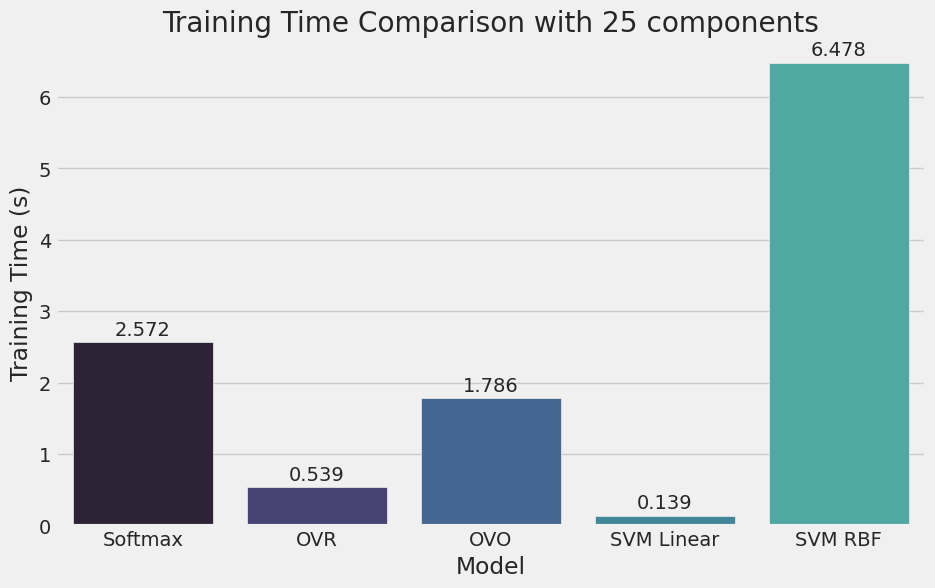

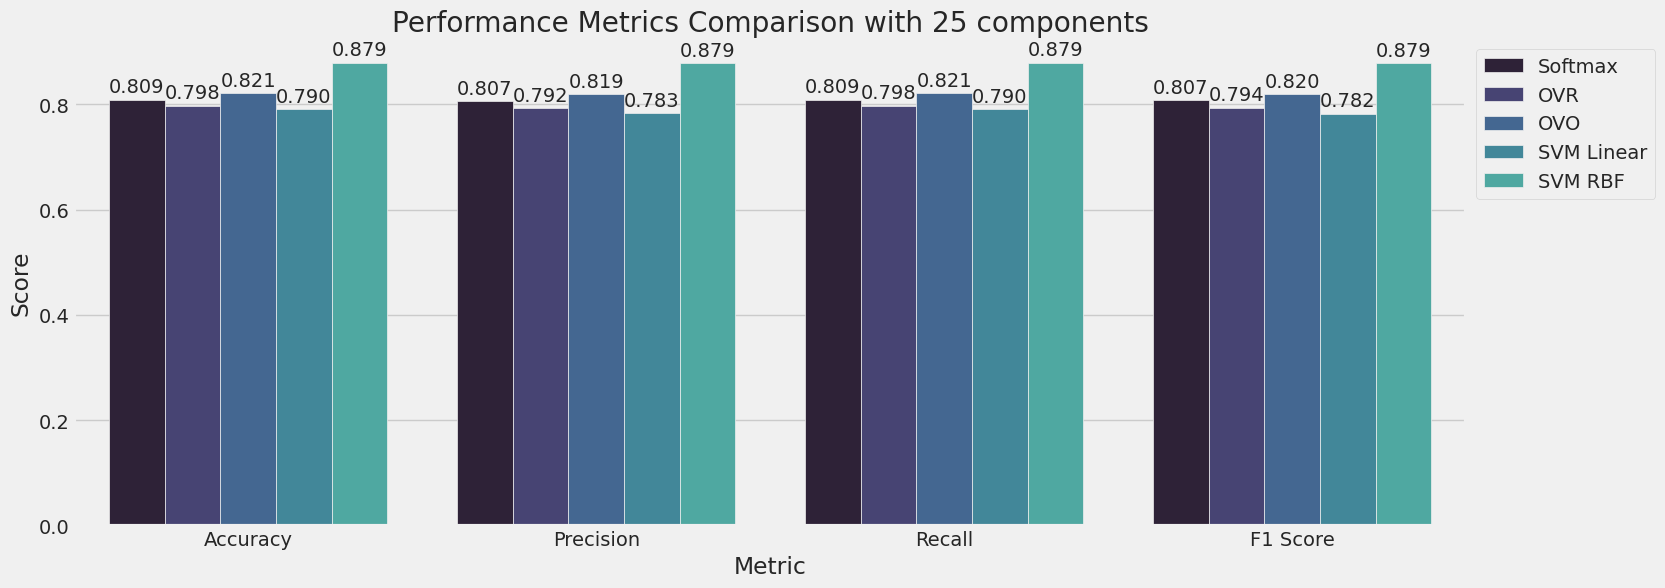

In [ ]:
custom_palette = sns.color_palette("mako", as_cmap=False)  # "viridis" is a gradient palette
sns.set_palette(custom_palette)

# Plotting training time comparison
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Training Time (s)', data=model_df)
plt.title('Training Time Comparison with 25 components')

# Hiển thị giá trị trên cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')
plt.show()

# Plotting performance metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
df_melted = model_df.melt(id_vars=['Model'], value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(16, 6))
ax = sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted)
plt.title('Performance Metrics Comparison with 25 components')

# Hiển thị giá trị trên cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()


> **Training Time (25 Components):**
* **SVM with Linear Kernel:** With a training time of 0.138 seconds, this model remains the most computationally efficient. The linear kernel's simplicity allows for quick training, making it suitable for applications that require fast retraining on large datasets.
* **OvR (One-vs-Rest):** At 0.539 seconds, the OvR model is still relatively fast. By training a single classifier per class, it remains efficient, though slightly slower than SVM Linear. This approach is practical in many multiclass scenarios without introducing significant computational overhead.
* **OvO (One-vs-One):** With a training time of 1.786 seconds, OvO is moderately fast but takes longer than both SVM Linear and OvR. This approach's complexity grows with the number of classes, as it requires one classifier for each class pair, increasing training time slightly.
* **Softmax:** Softmax has a training time of 2.572 seconds, which is lower than some models but still substantial. The iterative optimization required for Softmax, particularly for multiclass classification, likely contributes to its longer training time compared to linear kernel models.
* **SVM with RBF Kernel:** At 6.478 seconds, this model has the longest training time, due to the computational demands of the RBF kernel. The RBF kernel maps data into a higher-dimensional space to capture complex patterns, which is beneficial for accuracy but costly in terms of time.

> **Performance Metrics (25 Components):**
After reducing to 25 components, there is a slight decrease in performance metrics, which is expected given the reduction in dimensions. However, all models still maintain relatively high scores, with accuracy, precision, recall, and F1 scores ranging from approximately 0.79 to 0.88. This indicates that PCA with 25 components captures essential information, though some details are lost compared to 100 components.
* **SVM with RBF Kernel** continues to achieve the highest accuracy (0.8790), making it effective for capturing complex decision boundaries, even in reduced dimensions.
* **OvO** and **Softmax** maintain good performance, with OvO achieving a slightly higher accuracy (0.8210) than Softmax (0.8088), suggesting that they are both solid choices for multiclass problems with reduced dimensionality.
* **SVM Linear** has the lowest accuracy (0.7905), which suggests that while it is fast, it might not be the best choice when high accuracy is needed, especially on complex data.

In [ ]:
TrainingTimes = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'Training Time before PCA (s)': [softmax_training_time, ovr_training_time, ovo_training_time,svc_linear_training_time,svc_RBF_training_time],
     'Training Time after PCA (s)': [softmax_pca_training_time_25, ovr_pca_training_time, ovo_pca_training_time_25,svc_linear_pca_training_time_25,svc_RBF_pca_training_time_25]
}
df_training_times = pd.DataFrame(TrainingTimes)

Accuracy = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'Accuracy before PCA': [softmax_accuracy, ovr_accuracy, ovo_accuracy,svc_linear_accuracy,svc_RBF_accuracy],
    'Accuracy after PCA': [softmax_pca_accuracy_25, ovr_pca_accuracy_25, ovo_pca_accuracy_25,svc_linear_pca_accuracy_25,svc_RBF_pca_accuracy_25],
}
df_accuracy = pd.DataFrame(Accuracy)

Precision = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'Precision before PCA': [softmax_precision, ovr_precision, ovo_precision,svc_linear_precision,svc_RBF_precision],
    'Precision after PCA': [softmax_pca_precision_25, ovr_pca_precision_25, ovo_pca_precision_25,svc_linear_pca_precision_25,svc_RBF_pca_precision_25],
}
df_precision = pd.DataFrame(Precision)

Recall = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'Recall before PCA': [softmax_recall, ovr_recall, ovo_recall, svc_linear_recall, svc_RBF_recall],
    'Recall after PCA': [softmax_pca_recall_25, ovr_pca_recall_25, ovo_pca_recall_25, svc_linear_pca_recall_25, svc_RBF_pca_recall_25],
}
df_recall = pd.DataFrame(Recall)

F1_Score = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'F1 Score before PCA': [softmax_f1, ovr_f1_score, ovo_f1_score, svc_linear_f1, svc_RBF_f1],
    'F1 Score after PCA': [softmax_pca_f1_25, ovr_pca_f1_score_25, ovo_pca_f1_score_25, svc_linear_pca_f1_25, svc_RBF_pca_f1_25]
}
df_f1_score = pd.DataFrame(F1_Score)

In [ ]:
df_training_times

,Model,Training Time before PCA (s),Training Time after PCA (s)
0,Softmax,77.585387,2.572200
1,OVR,22.836686,0.538618
2,OVO,15.534057,1.786042
3,SVM Linear,3.850356,0.138574
4,SVM RBF,22.449022,6.477581


In [ ]:
df_accuracy

,Model,Accuracy before PCA,Accuracy after PCA
0,Softmax,0.8440,0.8088
1,OVR,0.8413,0.7977
2,OVO,0.8502,0.8210
3,SVM Linear,0.8417,0.7905
4,SVM RBF,0.9015,0.8790


In [ ]:
df_precision

,Model,Precision before PCA,Precision after PCA
0,Softmax,0.842817,0.806710
1,OVR,0.839202,0.792231
2,OVO,0.848965,0.819045
3,SVM Linear,0.838955,0.783171
4,SVM RBF,0.901396,0.878548


In [ ]:
df_recall

,Model,Recall before PCA,Recall after PCA
0,Softmax,0.8440,0.8088
1,OVR,0.8413,0.7977
2,OVO,0.8502,0.8210
3,SVM Linear,0.8417,0.7905
4,SVM RBF,0.9015,0.8790


In [ ]:
df_f1_score

,Model,F1 Score before PCA,F1 Score after PCA
0,Softmax,0.843185,0.807471
1,OVR,0.839608,0.793534
2,OVO,0.849482,0.819700
3,SVM Linear,0.839245,0.782412
4,SVM RBF,0.901404,0.878560


### Compare running time

In [ ]:
data = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
   'Non PCA': [softmax_training_time, ovr_training_time, ovo_training_time, svc_linear_training_time, svc_RBF_training_time, ],
   'PCA 100 components': [softmax_pca_100_training_time, ovr_pca_100_training_time, ovo_pca_100_training_time,svc_linear_pca_100_training_time,svc_RBF_pca_100_training_time],
   'PCA 25 components':  [softmax_pca_training_time_25, ovr_pca_training_time, ovo_pca_training_time_25,svc_linear_pca_training_time_25,svc_RBF_pca_training_time_25]
}
running_time_df = pd.DataFrame(data)

In [ ]:
running_time_df

,Model,Non PCA,PCA 100 components,PCA 25 components
0,Softmax,77.585387,6.973803,2.572200
1,OVR,22.836686,2.046878,0.538618
2,OVO,15.534057,3.233223,1.786042
3,SVM Linear,3.850356,0.355185,0.138574
4,SVM RBF,22.449022,9.365080,6.477581


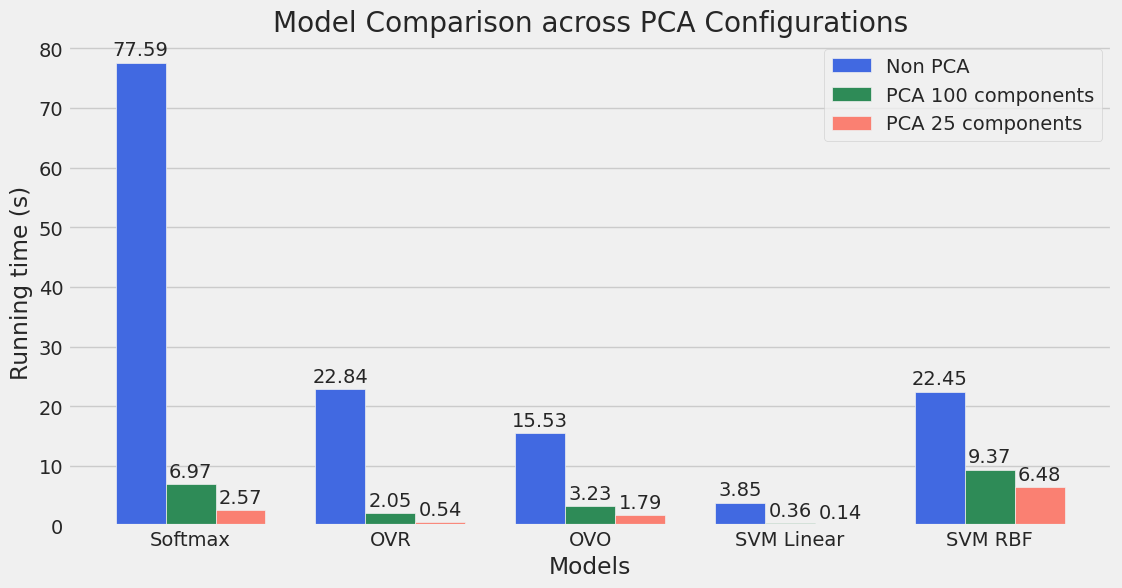

In [ ]:
custom_palette = sns.color_palette("mako", as_cmap=False)  # "viridis" is a gradient palette
sns.set_palette(custom_palette)

plt.figure(figsize=(12, 6))
bar_width = 0.25
x = np.arange(len(running_time_df['Model']))

# Vẽ từng thanh bar với các cấu hình PCA khác nhau
bars1 = plt.bar(x - bar_width, running_time_df['Non PCA'], width=bar_width, label='Non PCA', color='royalblue')
bars2 = plt.bar(x, running_time_df['PCA 100 components'], width=bar_width, label='PCA 100 components', color='seagreen')
bars3 = plt.bar(x + bar_width, running_time_df['PCA 25 components'], width=bar_width, label='PCA 25 components', color='salmon')

# Thêm nhãn trục và tiêu đề
plt.xlabel('Models')
plt.ylabel('Running time (s)')
plt.title('Model Comparison across PCA Configurations')
plt.xticks(x, running_time_df['Model'])
plt.grid(axis='x')
plt.legend()

# Thêm giá trị lên đầu mỗi cột
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.5, round(yval, 2), ha='center', va='bottom')

plt.show()

### **Model Analysis Across Different Dimensions (Original, 100 Components, and 25 Components)**

#### 1. **SVM with Linear Kernel**

- **Original Dimension**: The linear kernel SVM performs well in terms of computational efficiency with minimal training time due to its relatively simple decision boundary. However, in high-dimensional data, it may struggle to capture complex patterns, which can limit its accuracy compared to non-linear models.
- **100 Components**: When reduced to 100 components, the linear SVM model maintains high computational efficiency with minimal impact on accuracy. The reduced dimensions aid in lowering computational demands while preserving the main variance, allowing the model to remain both fast and accurate.
- **25 Components**: With 25 components, the linear SVM still benefits from quick training, but the lower dimensionality can lead to a slight drop in accuracy as it may not capture the data’s full complexity. This model is ideal in scenarios where speed is prioritized over marginal gains in accuracy.



#### 2. **SVM with RBF Kernel**

- **Original Dimension**: The RBF kernel SVM is highly accurate in capturing complex, non-linear relationships in the original high-dimensional data. However, this comes at a high computational cost, resulting in the longest training time among the models.
- **100 Components**: After dimensionality reduction to 100 components, the RBF SVM model retains its high accuracy while benefiting from reduced training time. The trade-off here favors maintaining predictive power while lowering computational demands.
- **25 Components**: With only 25 components, the RBF kernel’s training time remains relatively high, and there is a slight decrease in accuracy. This model’s computational burden may not be justified unless the highest possible accuracy is essential.



#### 3. **One-vs-Rest (OvR) Logistic Regression**

- **Original Dimension**: OvR logistic regression strikes a balance between accuracy and training time in high-dimensional space. It’s computationally feasible but may struggle with classes that have overlapping features.
- **100 Components**: With 100 components, OvR maintains reasonable accuracy and computational efficiency, as dimensionality reduction alleviates some of the computational load without significantly impacting performance.
- **25 Components**: At 25 components, OvR still performs well, though accuracy can decrease as some feature interactions may be lost. The reduced computational requirement makes it suitable for moderate datasets where speed is important.


#### 4. **One-vs-One (OvO) Logistic Regression**

- **Original Dimension**: The OvO model, which builds a separate classifier for each class pair, can achieve slightly better accuracy in high-dimensional space due to its finer-grained approach. However, this method is more computationally intensive as the number of classes increases.
- **100 Components**: Dimensionality reduction to 100 components reduces computational load for OvO while retaining reasonable accuracy, making it a balanced choice for multiclass classification.
- **25 Components**: With 25 components, OvO may see a slight decline in accuracy, but it still performs efficiently in computational terms. It’s suitable for applications where multiple classes need to be distinguished but computational resources are limited.


#### 5. **Softmax Logistic Regression**

- **Original Dimension**: Softmax is effective for multiclass classification but tends to be slower in high-dimensional data due to the iterative optimization required. It performs best in scenarios where interpretability and probabilistic outputs are valuable.
- **100 Components**: With 100 components, Softmax benefits from dimensionality reduction, achieving faster training while maintaining similar accuracy levels. This makes it a viable option when model interpretability and balanced multiclass performance are required.
- **25 Components**: With only 25 components, Softmax experiences a minor accuracy drop, but its reduced training time makes it suitable for situations where quick model iteration is necessary.

### **Conclusion**
> * In summary, SVM Linear and OvR are optimal for computational efficiency, especially as dimensionality decreases, making them ideal for rapid applications.
* SVM RBF and OvO offer higher accuracy at the cost of training time, suited for applications where accuracy outweighs computational cost.
* Softmax provides a balanced solution, excelling in interpretability, making it suitable for probabilistic multiclass problems.
